In [142]:
import os
import random
import time
import gc

import numpy as np
import pandas as pd
from IPython.display import display
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import torch.nn.functional as F

from datetime import date

from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_rows', None)

scaler = StandardScaler()
DATAPATH = 'external/amn_release/Dataset_model/e_coli_core_UB_15400.npz' 

In [143]:
def set_seed(seed=42):
    """
    Set all random seeds for reproducibility across different devices.
    
    Args:
        seed (int): Random seed value (default: 42)
    """
    # Python random module
    random.seed(seed)
    
    # NumPy
    np.random.seed(seed)
    
    # PyTorch CPU
    torch.manual_seed(seed)
    
    # PyTorch CUDA (NVIDIA GPUs)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  # For multi-GPU setups
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    
    # PyTorch MPS (Apple Silicon)
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)
    
    
    os.environ['PYTHONHASHSEED'] = str(seed)

In [144]:

def get_device(device_type=None):
    """
    Select device with manual override option
    
    Args:
        device_type: 'cuda', 'mps', 'cpu', or None for auto-selection
    """
    if device_type:
        return torch.device(device_type)
    
    if torch.cuda.is_available():
        return torch.device("cuda")
    elif torch.backends.mps.is_available():
        return torch.device("mps")
    else:
        return torch.device("cpu")

device = get_device()

print(f"Training on device: {device}")

print(f"PyTorch version: {torch.__version__}")

Training on device: mps
PyTorch version: 2.7.1


In [145]:
def print_gpu_memory():
    """
    Displays the current GPU memory usage by PyTorch on the active device (CUDA or MPS).
    Useful for monitoring GPU memory usage during training.
    """
    if torch.cuda.is_available():
        device = torch.cuda.current_device()
        allocated = torch.cuda.memory_allocated(device) / 1024**2
        reserved = torch.cuda.memory_reserved(device) / 1024**2
        print(f'CUDA Allocated memory: {allocated:.2f} MB')
        print(f'CUDA Reserved memory: {reserved:.2f} MB')
    elif torch.backends.mps.is_available():
        allocated = torch.mps.current_allocated_memory() / 1024**2
        reserved = torch.mps.driver_allocated_memory() / 1024**2
        print(f'MPS Allocated memory: {allocated:.2f} MB')
        print(f'MPS Driver allocated memory: {reserved:.2f} MB')
    else:
        print("Neither CUDA nor MPS is available.")

In [146]:
class AttentionBlock(nn.Module):
    """Custom multi-head attention block for metabolic modeling"""
    def __init__(self, d_model=8, n_heads=2, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"

        self.d_model = d_model
        self.n_heads = n_heads
        self.layer_norm = nn.LayerNorm(d_model)

        self.mha = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=n_heads,
            dropout=dropout,
            batch_first=True
        )

        self.head_scores = nn.Parameter(torch.zeros(n_heads))

    def forward(self, x, c):
        # x: (batch, seq_len, d_model)
        # c: (batch, seq_len, 1)
        x_norm = self.layer_norm(x) # pre-norm
        attn_out, attn_weights = self.mha(x_norm, x_norm, x_norm, need_weights=True, average_attn_weights=False)

        x_out = attn_out + x

        # Per-head diffusion of c:
        c_heads = torch.matmul(attn_weights, c.unsqueeze(1))
        alpha = F.softmax(self.head_scores, dim=0).view(1, self.n_heads, 1, 1)  # (1,H,1,1)
        c_att = (c_heads * alpha).sum(dim=1)  # (B, S, 1)

        c_out = c_att + c

        return x_out, c_out

In [147]:
# pre-norm

class FeedForwardBlock(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()

        self.d_model = d_model + 1
        self.d_ff = d_ff

        self.layer_norm = nn.LayerNorm(self.d_model)
        self.linear1 = nn.Linear(self.d_model, self.d_ff)
        self.activation = nn.GELU()
        self.linear2 = nn.Linear(self.d_ff, self.d_model)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, c):
        y = torch.cat((x, c), dim=2)
        
        norm_y = self.layer_norm(y)
        hidden = self.linear1(norm_y)
        hidden = self.activation(hidden)
        hidden = self.dropout(hidden)
        output = self.linear2(hidden)

        return output + y

In [148]:
class FluxTransformerLayer(nn.Module):
    """Single transformer block without embedding layer"""
    def __init__(self, d_model=8, n_heads=2, d_ff=128, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        
        self.attention_block = AttentionBlock(d_model, n_heads, dropout)
        self.feedforward_block = FeedForwardBlock(d_model, d_ff, dropout)
        
        self.apply(self._init_weights)
    
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
    
    def forward(self, x, c):
        attn_x, attn_c = self.attention_block(x, c)
        ff_output = self.feedforward_block(attn_x, attn_c)
        
        # Split the concatenated output
        updated_x = ff_output[:, :, :-1]
        updated_c = ff_output[:, :, -1:]
        
        return updated_x, updated_c

In [149]:
class FluxTransformer(nn.Module):
    def __init__(
        self,
        vocab_size=2742,
        d_model=128,
        n_heads=8,
        n_layers=3,
        d_ff=1024,
        dropout=0.2,
        input_length=30
    ):
        super().__init__()
        self.vocab_size = vocab_size
        self.d_model = d_model
        self.input_length = input_length

        self.input_embedding = nn.Embedding(vocab_size, d_model)

        self.layers = nn.ModuleList([
            FluxTransformerLayer(
                d_model=d_model,
                n_heads=n_heads,
                d_ff=d_ff,
                dropout=dropout
            )
            for _ in range(n_layers)
        ])

    def forward(self, c, output_subset=None, return_embedding=False):
        """
        Args:
            c: (batch, 1) or (batch, seq, 1) context tensor
            output_subset: 1D tensor of indices (subset of outputs) or None
            return_embedding: if True, return embeddings instead of c

        Returns:
            c: updated context
            selected_indices: indices of tokens used (always include inputs 0..29)
        """
        batch_size = c.size(0)

        # Always include input indices
        input_indices = torch.arange(self.input_length, device=c.device)

        if output_subset is None:
            selected_indices = torch.arange(self.vocab_size, device=c.device)
        else:
            # Concatenate inputs + sampled outputs
            selected_indices = torch.cat([input_indices, output_subset.to(c.device)])
            selected_indices = torch.unique(selected_indices, sorted=True)

        # Expand indices for batch
        y = selected_indices.unsqueeze(0).expand(batch_size, -1)  # (B, seq_subset)
        x = self.input_embedding(y)  # (B, seq_subset, d_model)

        # Slice c to selected indices
        c_subset = c[:, selected_indices, :]

        c_subset_all_layers = torch.zeros(batch_size, c_subset.size()[1], len(self.layers), device=c.device)

        for e,layer in enumerate(self.layers):
            x, c_subset = layer(x, c_subset)
            c_subset_all_layers[:, :, e] = c_subset.squeeze(-1)

        if return_embedding:
            return x, selected_indices  # embeddings + indices

        return c_subset_all_layers, selected_indices

In [150]:
def load_data(filepath=DATAPATH,separate=True):
    """
    Load and preprocess metabolic flux training data
    
    Parameters:
        filepath (str): Path to the .npz file.

    Returns:
        X_combined (ndarray): Combined input matrix (inputs in the first columns, outputs are zeros).
        y_combined (ndarray): Combined output matrix (inputs are zeros, outputs in the last columns).
        all_columns (list): List of column names (input + output).
    """
    data = np.load(filepath)
    X = data['X']
    y = data['Y']
    inp_cols = [str(s) for s in data['medium']]
    out_cols = [str(s) for s in data['measure']]
    if separate:

        # Normalize the output targets
        #scaler = StandardScaler()
        #y_normalized = scaler.fit_transform(y)

        X_combined = np.hstack([X, np.zeros_like(y)])
        y_combined = np.hstack([np.zeros_like(X), y])

        return X_combined, y_combined, inp_cols, out_cols, data['S']
    else:
        X_ = np.zeros_like(y)

        out_indices = set([ i for i in range(y.shape[1]) ])
        inp_indices = []
        for idx_inp,i in enumerate(inp_cols):
            if i in out_cols:
                idx_out = out_cols.index(i)
                X_[:, idx_out] = X[:, idx_inp]
                out_indices.remove(idx_out)
                inp_indices.append(idx_out)

        out_indices = list(out_indices)
        out_indices.sort()

        inp_indices.sort()

        return X_, y, inp_indices, out_indices, inp_cols, out_cols, data['S']


In [ ]:
def prepare_tensors(X, y, test_size=0.4, device="cpu"):
    """
    Split data into train/test and convert to PyTorch tensors.
    
    Parameters:
        X (ndarray): Input features.
        y (ndarray): Output targets.
        test_size (float): Fraction of data to reserve for testing.
        device (str or torch.device): Device to move tensors to.
    
    Returns:
        X_train_tensor, X_test_tensor, y_train_tensor, y_test_tensor (torch.Tensor)
    """
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)

    # y_train_scaled = scaler.fit_transform(y_train)
    # y_test_scaled = scaler.transform(y_test)

    print(f"Training samples: {len(X_train)}")
    print(f"Test samples: {len(X_test)}")

    X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).to(device)
    y_test_tensor = torch.tensor(y_test, dtype=torch.float32).to(device)

    return X_train_tensor, X_test_tensor, y_train_tensor, y_test_tensor

In [152]:
def create_dataloaders(X_train, y_train, X_test, y_test, batch_size):
    """
    Create PyTorch DataLoaders for training and testing.

    Parameters:
        X_train, y_train (Tensor): Training data and labels.
        X_test, y_test (Tensor): Test data and labels.
        batch_size (int): Batch size for loading.

    Returns:
        train_loader, test_loader (DataLoader): PyTorch DataLoaders.
    """
    train_dataset = TensorDataset(X_train.unsqueeze(-1), y_train.unsqueeze(-1))
    test_dataset = TensorDataset(X_test.unsqueeze(-1), y_test.unsqueeze(-1))

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, test_loader

In [153]:
# # Load and preprocess data

# X, y, input_cols, output_cols, S = load_data(DATAPATH)
# X_train, X_test, y_train, y_test = prepare_tensors(X, y, device=device)
# train_loader, test_loader = create_dataloaders(X_train, y_train, X_test, y_test, batch_size=128)

In [154]:
# Load and preprocess data

X, y, inp_indices, out_indices, inp_names, output_cols, S = load_data(DATAPATH,separate=False)
X_train, X_test, y_train, y_test = prepare_tensors(X, y, device=device)
train_loader, test_loader = create_dataloaders(X_train, y_train, X_test, y_test, batch_size=128)

Training samples: 9240
Test samples: 6160


In [155]:
def train_model(
    d_model=128,
    n_heads=8,
    n_layers=3,
    d_ff=640,
    num_epochs=100,
    learning_rate=0.001,
    dropout=0.02,
    output_sample_ratio=0.5
):
    start_time = time.time()

    model = FluxTransformer(
        vocab_size=len(output_cols),
        d_model=d_model,
        n_heads=n_heads,
        n_layers=n_layers,
        d_ff=d_ff,
        dropout=dropout
    ).to(device)
    
    optimizer = optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        betas=(0.9, 0.98),
        eps=1e-9,
        weight_decay=1e-5
    )
    criterion = nn.HuberLoss()

    best_test_loss = float('inf')
    best_epoch = -1

    train_losses = []
    test_losses = []

    total_outputs = len(output_cols)-len(inp_names)
    #output_start_idx = len(input_cols)

    for epoch in range(num_epochs):
        model.train()
        epoch_train_loss = 0.0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()

            # Randomly sample subset of outputs
            if output_sample_ratio >= 1.0:
                sampled_indices = None  # pass None to FluxTransformer.forward()
            else:
                n_sampled = max(1, int(total_outputs * output_sample_ratio))
                sampled_indices = torch.tensor(
                    random.sample(out_indices, n_sampled),
                    device=device
                )

            #print(batch_X.size(),batch_y.size())
            
            predictions, selected_indices = model(batch_X, output_subset=sampled_indices)
            
            target = batch_y[:, selected_indices, :]
            
            # print(predictions.size(),target.size())
            # print(predictions[:,:,-1].unsqueeze(2).size(),target.size())

            loss = criterion(predictions[:,:,-1].unsqueeze(2), target)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_train_loss += loss.item() * batch_X.size(0)

            # Explicitly free tensors
            del predictions, loss
            if device.type == 'cuda':
                torch.cuda.empty_cache()
            elif device.type == 'mps':
                torch.mps.empty_cache()
        
        epoch_train_loss /= len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        # Evaluation
        model.eval()
        epoch_test_loss = 0.0
        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                n_sampled = max(1, int(total_outputs * output_sample_ratio))
                sampled_indices = torch.tensor(
                                random.sample(out_indices, n_sampled),
                                device=device
                )

                predictions, selected_indices = model(batch_X, output_subset=sampled_indices)
                target = batch_y[:, selected_indices, :]
                loss = criterion(predictions[:,:,-1].unsqueeze(2), target)

                epoch_test_loss += loss.item() * batch_X.size(0)

                # Explicitly free tensors
                del predictions, loss
                if device.type == 'cuda':
                    torch.cuda.empty_cache()
                elif device.type == 'mps':
                    torch.mps.empty_cache()
        
        epoch_test_loss /= len(test_loader.dataset)
        test_losses.append(epoch_test_loss)

        if (epoch+1) % 2 == 0:
            print(f"Epoch {epoch+1}/{num_epochs} | "
                f"Train Loss: {epoch_train_loss:.6f} | "
                f"Test Loss: {epoch_test_loss:.6f}")
        
        if epoch_test_loss < best_test_loss:
            best_test_loss = epoch_test_loss
            best_epoch = epoch + 1
        
        # Additional memory cleanup after epoch
        if device.type == 'cuda':
            torch.cuda.empty_cache()
        elif device.type == 'mps':
            torch.mps.empty_cache()
        gc.collect()

    print('Training Completed.')
    end_time = time.time()
    elapsed_time = end_time - start_time
    mins, secs = divmod(elapsed_time, 60)
    print(f"Training took {int(mins)} min {secs:.1f} sec.")
    print(f"Best test loss: {best_test_loss:.6f} at epoch {best_epoch}")
    
    return train_losses, test_losses, model, optimizer

In [156]:
d_model = 128
n_heads = 8
n_layers = 3
d_ff = 640
batch_size = 128
num_epochs = 40
learning_rate = 1e-4
dropout = 0.02
output_sample_ratio = 1

diagnostics_to_plot = ['BIOMASS_Ecoli_core_w_GAM', 'GLUDy_for']

In [157]:
print_gpu_memory()

MPS Allocated memory: 32.34 MB
MPS Driver allocated memory: 176.41 MB


In [158]:
train_losses, test_losses, model_822, optimizer = train_model(d_model=8, n_heads=2, n_layers=2, d_ff=128, num_epochs=num_epochs, dropout=dropout,output_sample_ratio=output_sample_ratio)

# plot_loss_curves(train_losses, test_losses, d_model=8, n_heads=2, n_layers=2, d_ff=128)

# plot_prediction_sample(X_test, y_test, model_822)

# for flux_name in diagnostics_to_plot:
#     plot_flux(model_822, X_test, y_test, output_cols, flux_name)

# print('Number of parameters:')
# print(sum( p.numel() for p in model_822.parameters() if p.requires_grad ))

Epoch 2/40 | Train Loss: 0.374874 | Test Loss: 0.283525
Epoch 4/40 | Train Loss: 0.210864 | Test Loss: 0.307648
Epoch 6/40 | Train Loss: 0.193482 | Test Loss: 0.311032
Epoch 8/40 | Train Loss: 0.182045 | Test Loss: 0.391102
Epoch 10/40 | Train Loss: 0.167632 | Test Loss: 0.417180
Epoch 12/40 | Train Loss: 0.149133 | Test Loss: 0.399077
Epoch 14/40 | Train Loss: 0.137155 | Test Loss: 0.350895
Epoch 16/40 | Train Loss: 0.128252 | Test Loss: 0.328058
Epoch 18/40 | Train Loss: 0.118287 | Test Loss: 0.337372
Epoch 20/40 | Train Loss: 0.110674 | Test Loss: 0.345920
Epoch 22/40 | Train Loss: 0.102680 | Test Loss: 0.342376
Epoch 24/40 | Train Loss: 0.096932 | Test Loss: 0.355264
Epoch 26/40 | Train Loss: 0.092515 | Test Loss: 0.337074
Epoch 28/40 | Train Loss: 0.088810 | Test Loss: 0.336359
Epoch 30/40 | Train Loss: 0.086587 | Test Loss: 0.329805
Epoch 32/40 | Train Loss: 0.084475 | Test Loss: 0.329645
Epoch 34/40 | Train Loss: 0.082941 | Test Loss: 0.326799
Epoch 36/40 | Train Loss: 0.081297 

In [160]:
def plot_loss_curves(train_losses, test_losses, d_model, n_heads, n_layers, d_ff, save_path=None, log_scale=True):
    plt.figure(figsize=(14, 10))
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.plot(train_losses, label="Training Loss")
    plt.plot(test_losses, label="Test Loss")
    if log_scale:
        plt.yscale('log')
    plt.xlabel("Epoch", fontsize=18)
    plt.ylabel("Loss", fontsize=18)
    plt.title(f"Loss Curves (d={d_model}, h={n_heads}, l={n_layers}, ff={d_ff})", fontsize=20)
    plt.grid(True)
    plt.legend(fontsize=16)
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path)
        plt.close()
        print(f"\nTraining curve saved to {save_path}")
    else:
        plt.show()

In [117]:
def plot_diagnostics_2x2(y_true, y_pred, label):
    """Creates a 2x2 matrix of plots: true vs predicted, residuals, error distribution, and histogram of samples"""
    residuals = y_true - y_pred

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))
    
    # True vs Predicted
    axs[0, 0].scatter(y_true, y_pred, alpha=0.2, s=5, color='royalblue')
    axs[0, 0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'k--', lw=2)
    axs[0, 0].set_title(f'True vs Predicted: {label}')
    axs[0, 0].set_xlabel('True value')
    axs[0, 0].set_ylabel('Predicted')
    axs[0, 0].grid(True)

    # Residuals plot
    axs[0, 1].scatter(y_true, residuals, alpha=0.15, color='darkorange')
    axs[0, 1].axhline(y=0, color='r', linestyle='-')
    axs[0, 1].set_title(f'Residuals: {label}')
    axs[0, 1].set_xlabel('True value')
    axs[0, 1].set_ylabel('Residuals')
    axs[0, 1].grid(True)

    # Error distribution
    sns.histplot(residuals, kde=True, ax=axs[1, 0], legend=False, color='indianred')
    axs[1, 0].set_title(f'Prediction Error Distribution: {label}')
    axs[1, 0].set_xlabel('Prediction Error')
    axs[1, 0].set_ylabel('Frequency')
    axs[1, 0].grid(True)

    # Histogram of actual values
    sns.histplot(y_true, kde=True, bins=100, ax=axs[1, 1], legend=False, color='mediumseagreen')
    axs[1, 1].set_title(f'True Value Distribution: {label}')
    axs[1, 1].set_xlabel('True Value')
    axs[1, 1].set_ylabel('Frequency')
    axs[1, 1].grid(True)

    plt.tight_layout()
    plt.show()
    plt.close()

In [118]:
def plot_prediction_sample(X_test, y_test, model):
    X_test_ = X_test.unsqueeze(-1)
    y_test_ = y_test.unsqueeze(-1)
    j = np.random.randint(0, X_test_.size(0), 1)[0]
    with torch.no_grad():
        pred, _ = model(X_test_[j].unsqueeze(0))
    true = y_test_[j].unsqueeze(0)
    # plt.plot(pred[0,:,-1].cpu().detach().numpy(), label='Predicted')
    # plt.plot(true[0,:,0].cpu().detach().numpy(), label='True')
    plt.figure(figsize=(14, 7))
    plt.plot(pred[0, :, -1].cpu().detach().numpy(), label='Predicted', color='royalblue', linewidth=2, marker='o', markersize=4, alpha=0.8)
    plt.plot(true[0, :, 0].cpu().detach().numpy(), label='True', color='darkorange', linewidth=2, marker='s', markersize=4, alpha=0.7)
    for flux_name in diagnostics_to_plot:
        if flux_name in output_cols:
            idx = output_cols.index(flux_name)
            plt.axvline(x=idx, color='green', linestyle='--', linewidth=2, label=f'{flux_name} (idx {idx})')
    #plt.axvline(x=32, color='crimson', linestyle='--', linewidth=2, label='Biomass (idx 32)')
    plt.legend(fontsize=14, frameon=True)
    plt.title(f"Sample Prediction vs True (Sample index {j})", fontsize=18, fontweight='bold')
    plt.xlabel("Reaction ID", fontsize=16)
    plt.ylabel("Rate", fontsize=16)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

In [119]:
def plot_flux(
    model,
    X_test,
    y_test,
    output_cols,
    flux_name: str,
):
    """ Displays a 2x2 diagnostic plot for the chosen flux."""

    #model.eval()
    model_cpu = model.to('cpu')  # move model to CPU
    model_cpu.eval()

    with torch.no_grad():
        y_pred_tensor, _ = model_cpu(X_test.unsqueeze(-1).to('cpu'))  # shape: [n_samples, 115, 1]
        #y_pred_tensor = model(X_test.unsqueeze(-1).to(device))  # shape: [n_samples, 115, 1]

    y_pred_full = y_pred_tensor.squeeze(-1).cpu().numpy()  # shape: [n_samples, 115]
    y_true_full = y_test.cpu().numpy()                     # shape: [n_samples, 115]

    # Extract only the output predictions (last 154 columns)
    y_pred_outputs = y_pred_full[:, :,-1]
    y_true_outputs = y_true_full
    print(y_pred_outputs.shape,y_true_full.shape)

    print("y_pred_outputs.shape:", y_pred_outputs.shape,
            "min/max:", y_pred_outputs.min(), y_pred_outputs.max())
    print("y_true_outputs.shape:", y_true_outputs.shape,
            "min/max:", y_true_outputs.min(), y_true_outputs.max())

    try:
        idx = output_cols.index(flux_name)
    except ValueError:
        raise ValueError(f"Flux '{flux_name}' not found in output_cols")

    # Verify the correct column
    print(f"{flux_name} index in outputs: {idx}")
    print(f"y_true_outputs[:, idx] range:",
            y_true_outputs[:, idx].min(), "to", y_true_outputs[:, idx].max())
    print(f"y_pred_outputs[:, _idx] range:",
            y_pred_outputs[:, idx].min(), "to", y_pred_outputs[:, idx].max())

    # Plot diagnostics specifically for given flux
    plot_diagnostics_2x2(
        y_true=y_true_outputs[:, idx],
        y_pred=y_pred_outputs[:, idx],
        label=flux_name
    )

In [120]:
def evaluate_metrics(model, X_test, y_test, output_cols, device='cpu', batch_size=16):
    """
    Evaluate a trained FluxTransformer model on test data.

    Args:
        model (nn.Module): Trained PyTorch model.
        X_test (Tensor): Test inputs, shape [n_samples, input+output features].
        y_test (Tensor): Test outputs, shape [n_samples, input+output features].
        output_cols (list of str): Names of output flux columns.
        device (str or torch.device): Device to run evaluation on.

    Returns:
        pd.DataFrame: DataFrame with columns ['flux', 'r2', 'mae'].
    """
    model = model.to(device)
    model.eval()

    y_preds = []
    y_trues = []
    
    n_samples = X_test.size(0)
    
    with torch.no_grad():
        for start in range(0, n_samples, batch_size):
            end = min(start + batch_size, n_samples)
            x_batch = X_test[start:end].unsqueeze(-1).to(device)
            y_batch = y_test[start:end].to(device)
            
            y_pred_tensor, _ = model(x_batch)
            y_preds.append(y_pred_tensor.squeeze(-1).cpu())
            y_trues.append(y_batch.cpu())
    
    y_pred = torch.cat(y_preds, dim=0).numpy()[:, 20:]  # skip input indices
    y_true = torch.cat(y_trues, dim=0).numpy()[:, 20:]

    metrics = []
    for i, label in enumerate(output_cols):
        r2 = r2_score(y_true[:, i], y_pred[:, i])
        mae = mean_absolute_error(y_true[:, i], y_pred[:, i])
        metrics.append({'flux': label.replace('_flux',''), 'r2': r2, 'mae': mae})

    df_metrics = pd.DataFrame(metrics)
    df_metrics['r2'] = df_metrics['r2'].map('{:.3f}'.format)
    df_metrics['mae'] = df_metrics['mae'].map('{:.4f}'.format)
    
    return df_metrics

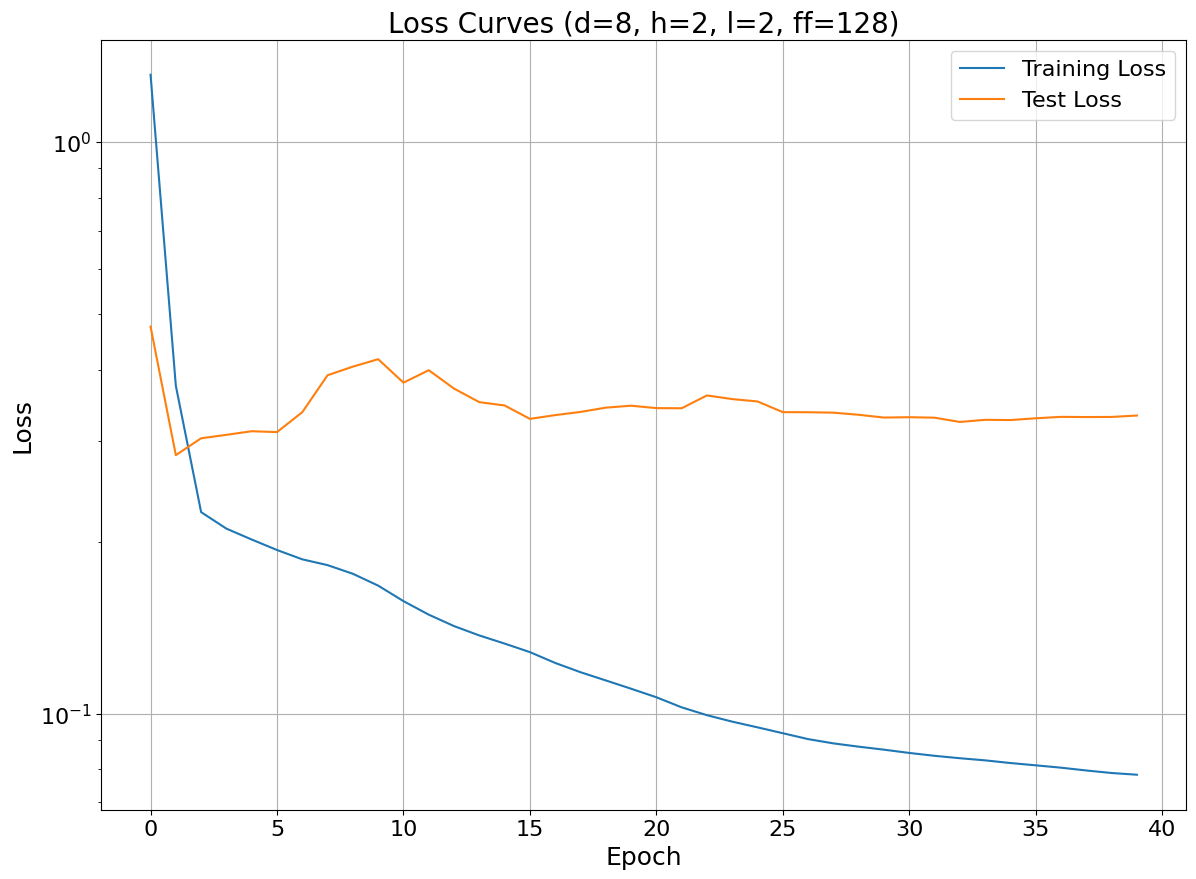

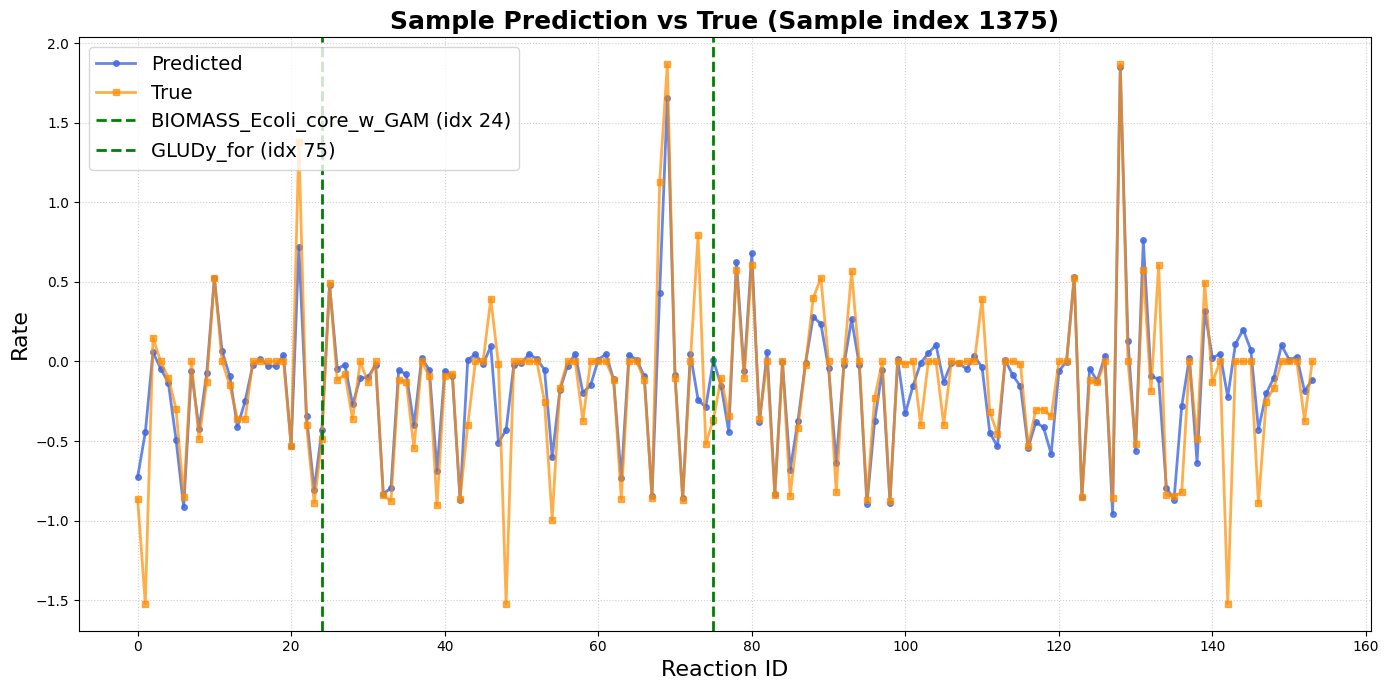

(6160, 154) (6160, 154)
y_pred_outputs.shape: (6160, 154) min/max: -2.437604 3.7039957
y_true_outputs.shape: (6160, 154) min/max: -18.982834 113.40801
BIOMASS_Ecoli_core_w_GAM index in outputs: 24
y_true_outputs[:, idx] range: -2.1844559 to 3.183293
y_pred_outputs[:, _idx] range: -1.5376034 to 2.155256


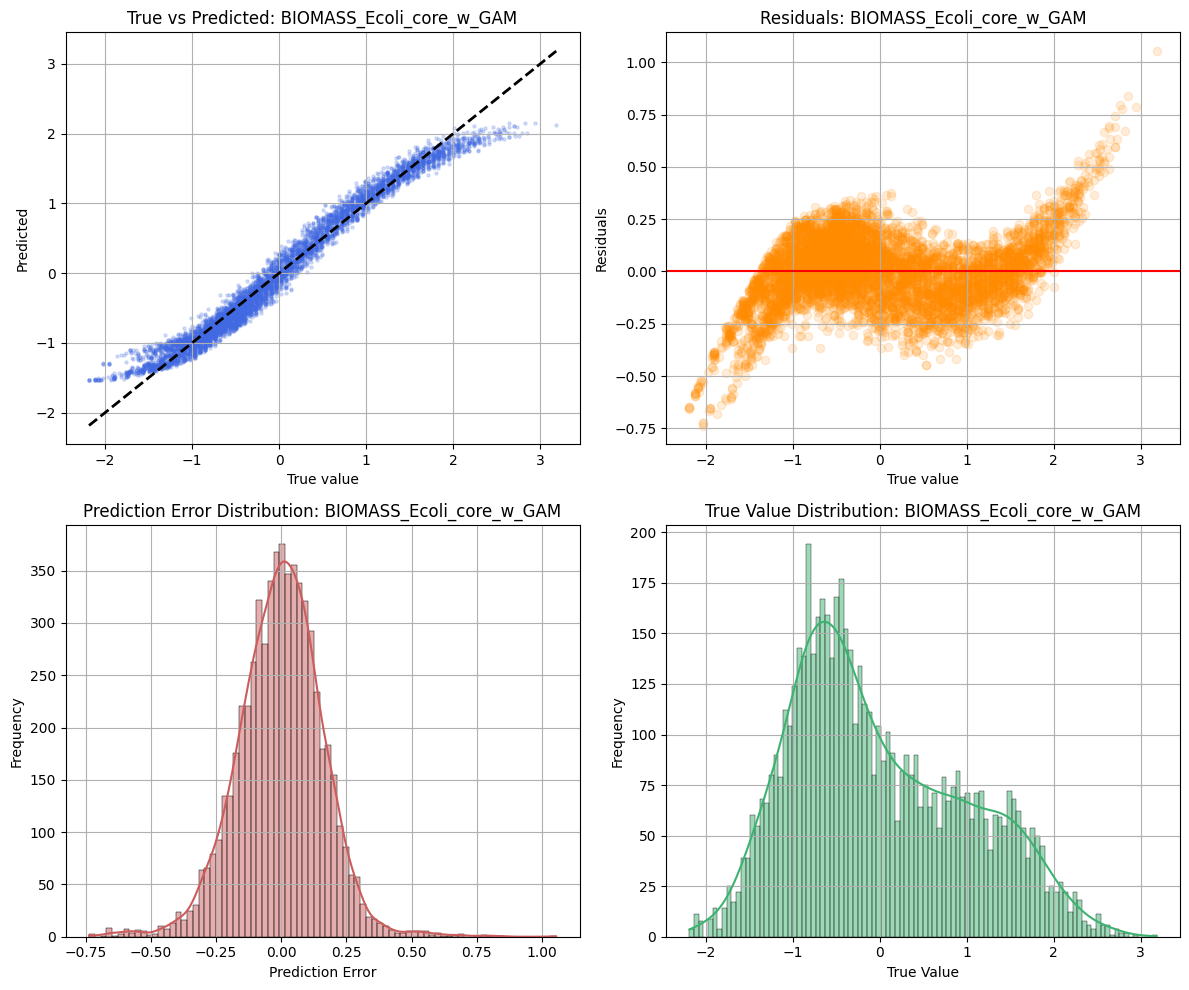

(6160, 154) (6160, 154)
y_pred_outputs.shape: (6160, 154) min/max: -2.437604 3.7039957
y_true_outputs.shape: (6160, 154) min/max: -18.982834 113.40801
GLUDy_for index in outputs: 75
y_true_outputs[:, idx] range: -0.3646894 to 5.3802166
y_pred_outputs[:, _idx] range: -0.55217034 to 0.501736


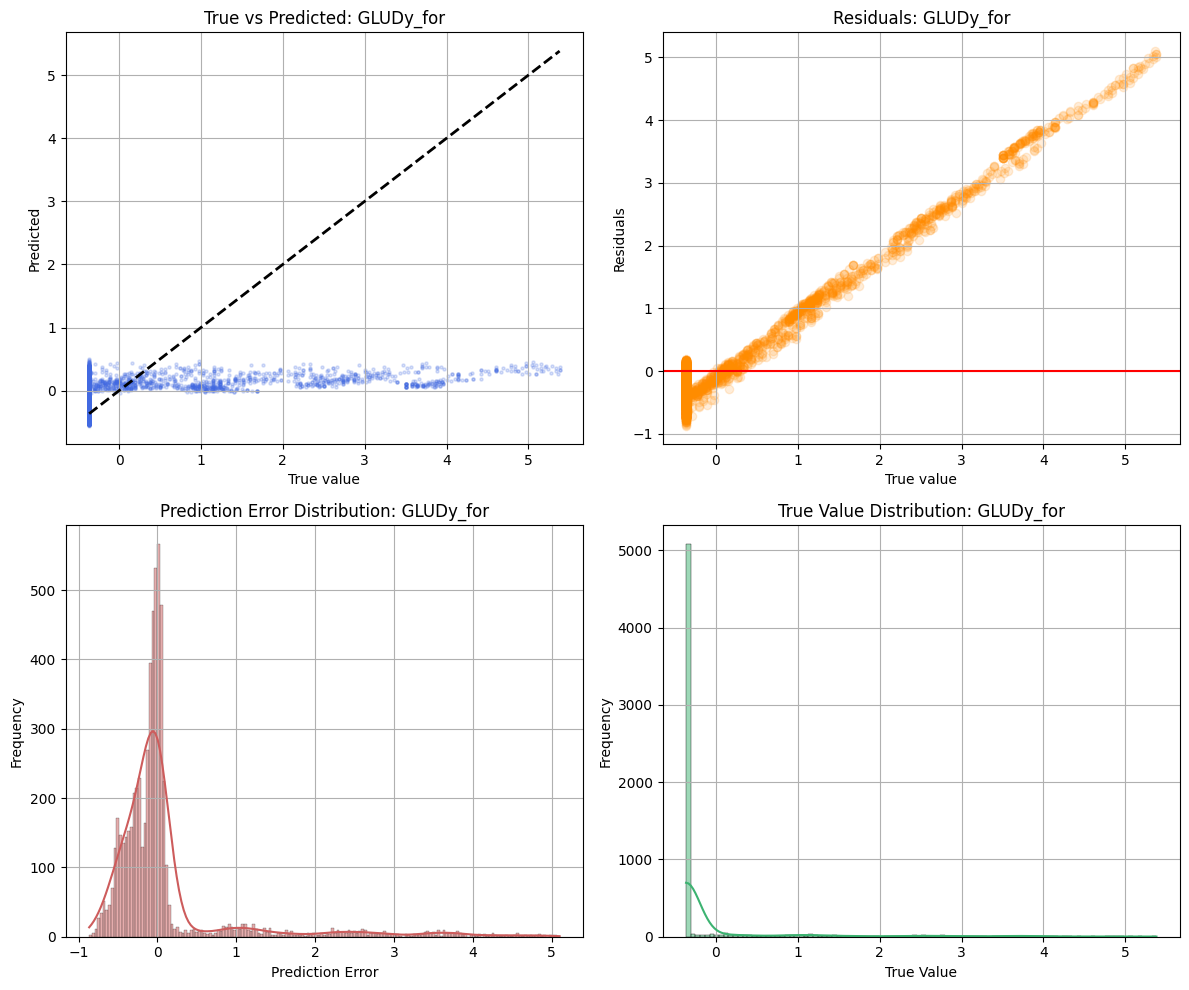

Number of parameters:
6762


In [161]:
model_822.to('mps')
plot_loss_curves(train_losses, test_losses, d_model=8, n_heads=2, n_layers=2, d_ff=128)

plot_prediction_sample(X_test, y_test, model_822)

for flux_name in diagnostics_to_plot:
    plot_flux(model_822, X_test, y_test, output_cols, flux_name)

print('Number of parameters:')
print(sum( p.numel() for p in model_822.parameters() if p.requires_grad ))

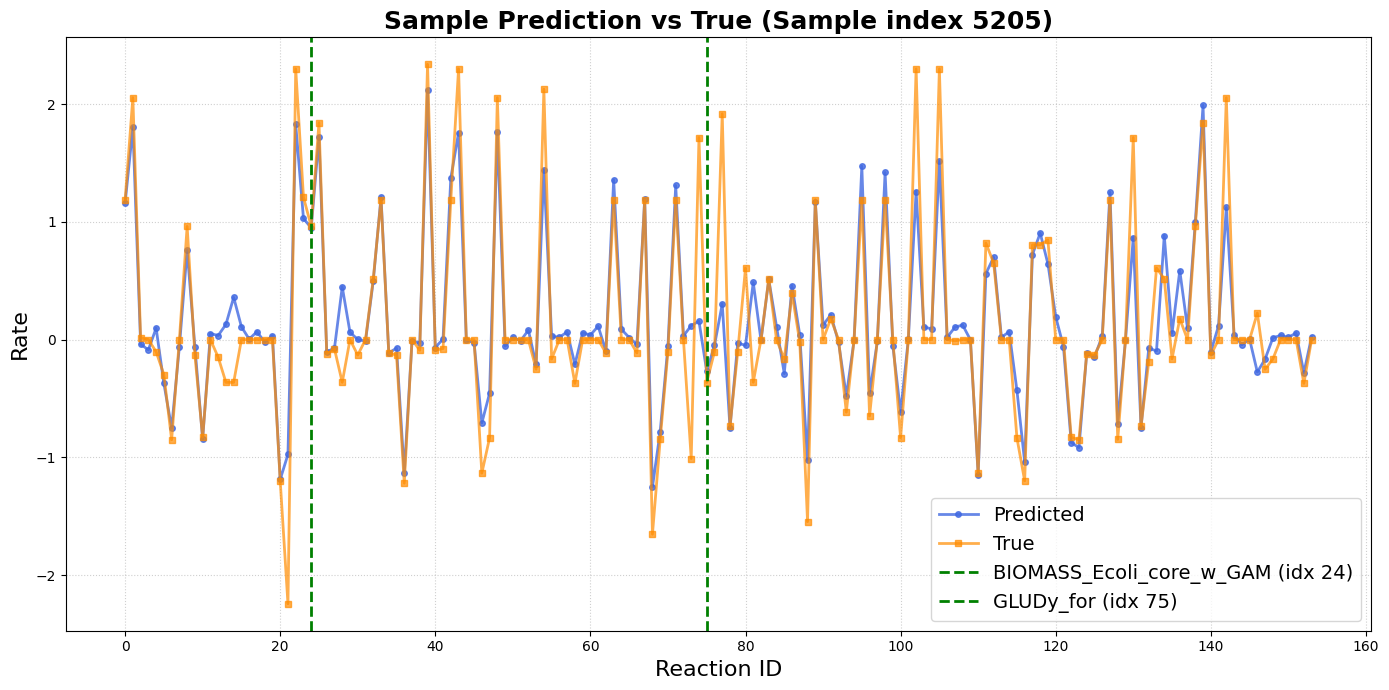

In [162]:
model_822.to('mps')
plot_prediction_sample(X_test, y_test, model_822)

In [163]:
train_losses_1622, test_losses_1622, model_1622, optimizer = train_model(d_model=16, n_heads=2, n_layers=2, d_ff=128, num_epochs=num_epochs, dropout=dropout,output_sample_ratio=output_sample_ratio)

plot_loss_curves(train_losses_1622, test_losses_1622, d_model=16, n_heads=2, n_layers=2, d_ff=128)

plot_prediction_sample(X_test, y_test, model_1622)

for flux_name in diagnostics_to_plot:
    plot_flux(model_1622, X_test, y_test, output_cols, flux_name)

print('Number of parameters:')
print(sum( p.numel() for p in model_1622.parameters() if p.requires_grad ))

Epoch 2/40 | Train Loss: 0.296331 | Test Loss: 0.253295
Epoch 4/40 | Train Loss: 0.185322 | Test Loss: 0.272267
Epoch 6/40 | Train Loss: 0.151351 | Test Loss: 0.265584
Epoch 8/40 | Train Loss: 0.122444 | Test Loss: 0.274544
Epoch 10/40 | Train Loss: 0.110528 | Test Loss: 0.281713
Epoch 12/40 | Train Loss: 0.099181 | Test Loss: 0.279019
Epoch 14/40 | Train Loss: 0.093832 | Test Loss: 0.282926
Epoch 16/40 | Train Loss: 0.089253 | Test Loss: 0.281301
Epoch 18/40 | Train Loss: 0.086180 | Test Loss: 0.276742
Epoch 20/40 | Train Loss: 0.080990 | Test Loss: 0.282832
Epoch 22/40 | Train Loss: 0.075485 | Test Loss: 0.284700
Epoch 24/40 | Train Loss: 0.072495 | Test Loss: 0.279320
Epoch 26/40 | Train Loss: 0.069851 | Test Loss: 0.285842
Epoch 28/40 | Train Loss: 0.067730 | Test Loss: 0.292268
Epoch 30/40 | Train Loss: 0.066014 | Test Loss: 0.295213
Epoch 32/40 | Train Loss: 0.064616 | Test Loss: 0.293213


KeyboardInterrupt: 

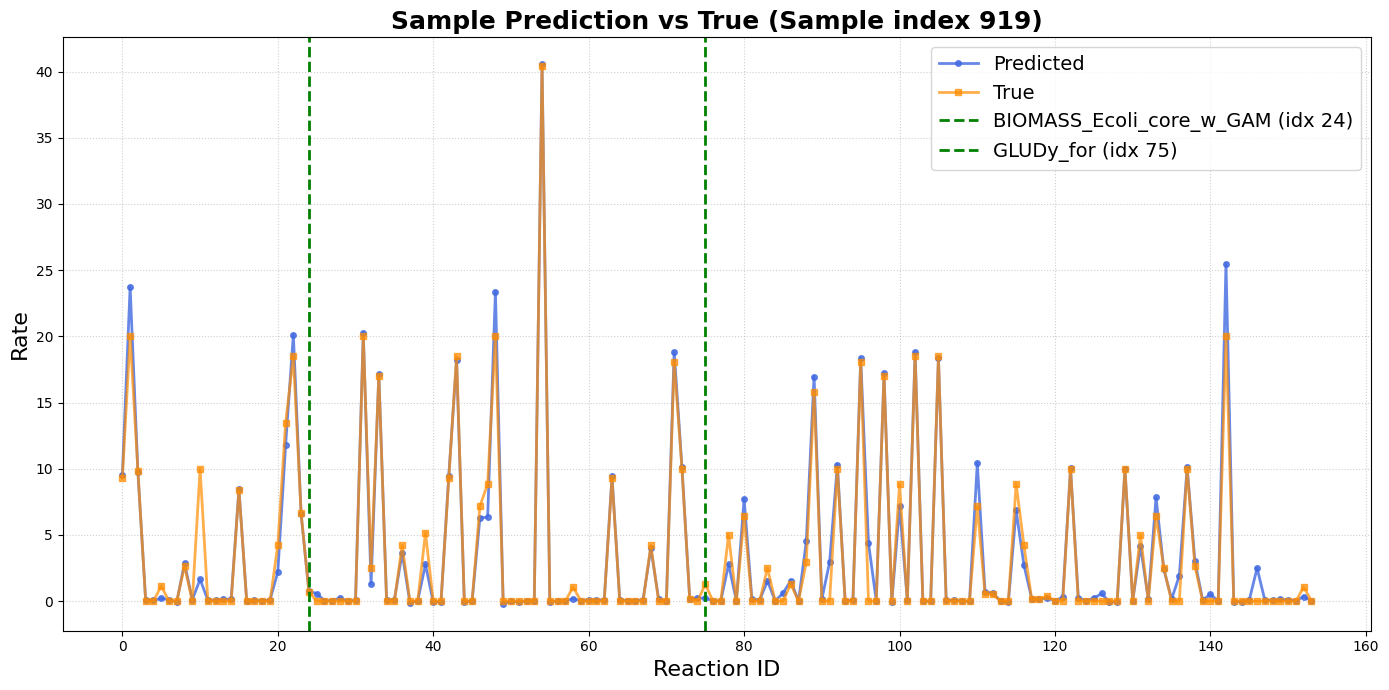

In [127]:
model_1622.to('mps')
plot_prediction_sample(X_test, y_test, model_1622)

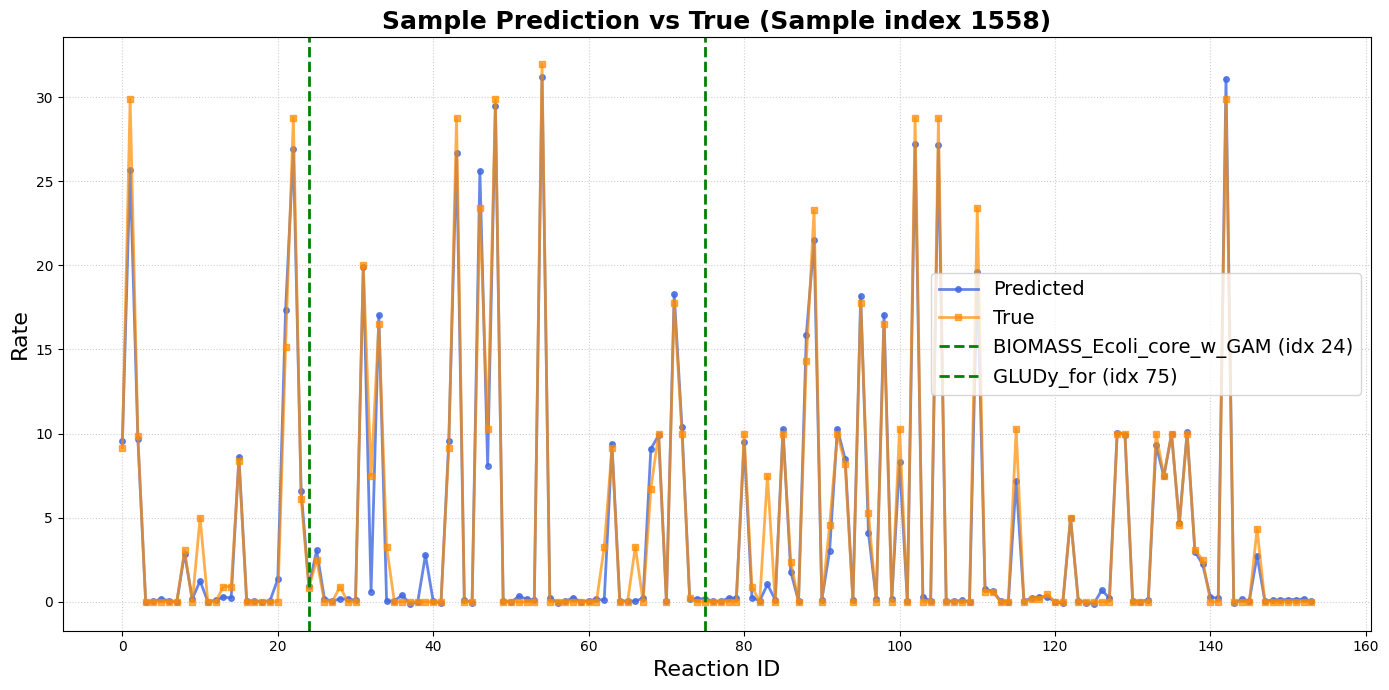

(6160, 154) (6160, 154)
y_pred_outputs.shape: (6160, 154) min/max: -1.4844637 79.69843
y_true_outputs.shape: (6160, 154) min/max: 0.0 86.397766
BIOMASS_Ecoli_core_w_GAM index in outputs: 24
y_true_outputs[:, idx] range: 0.5590506 to 1.2481481
y_pred_outputs[:, _idx] range: 0.5619594 to 1.2216761


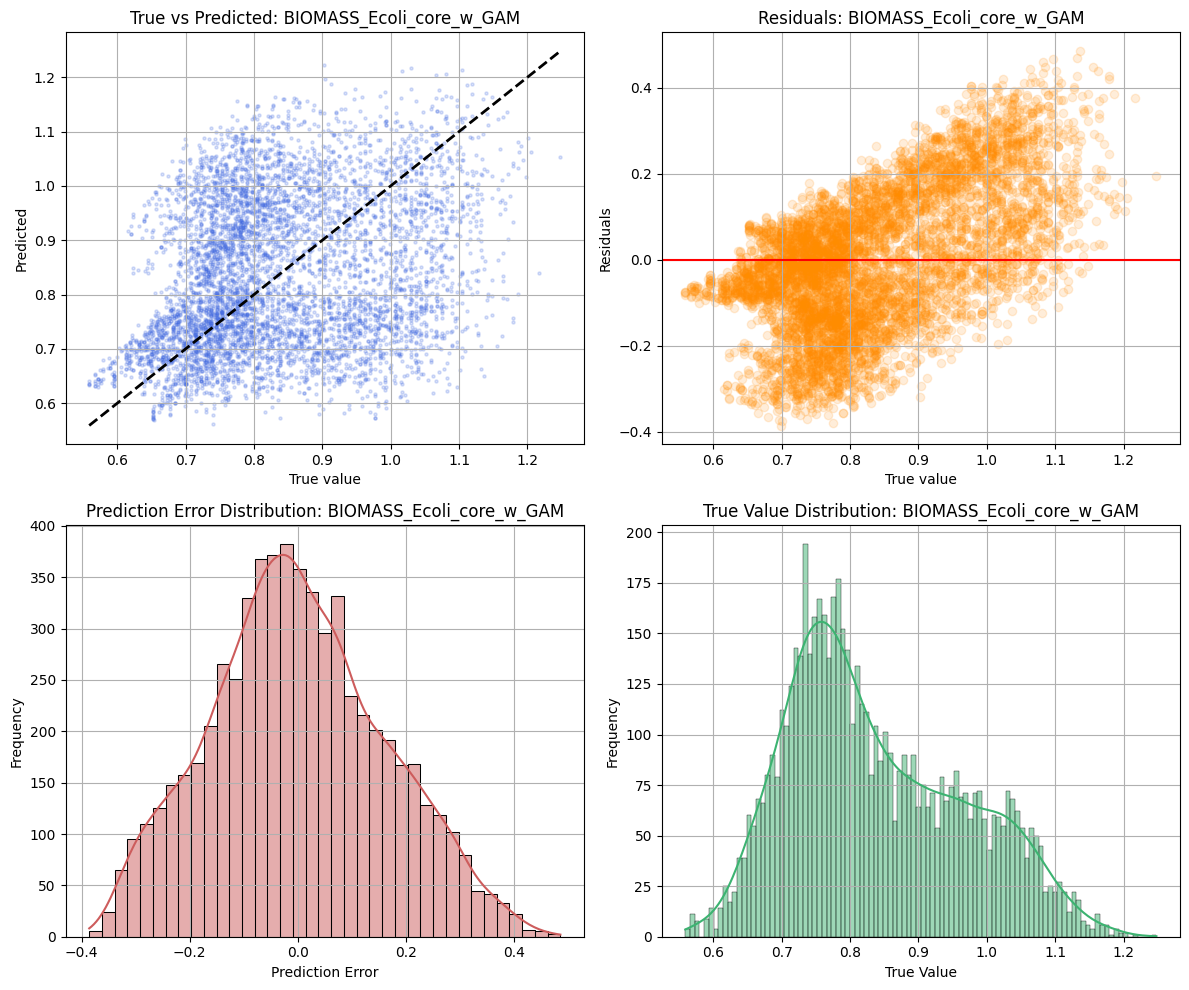

(6160, 154) (6160, 154)
y_pred_outputs.shape: (6160, 154) min/max: -1.4844637 79.69843
y_true_outputs.shape: (6160, 154) min/max: 0.0 86.397766
GLUDy_for index in outputs: 75
y_true_outputs[:, idx] range: 0.0 to 5.187185
y_pred_outputs[:, _idx] range: -0.01805675 to 0.4877066


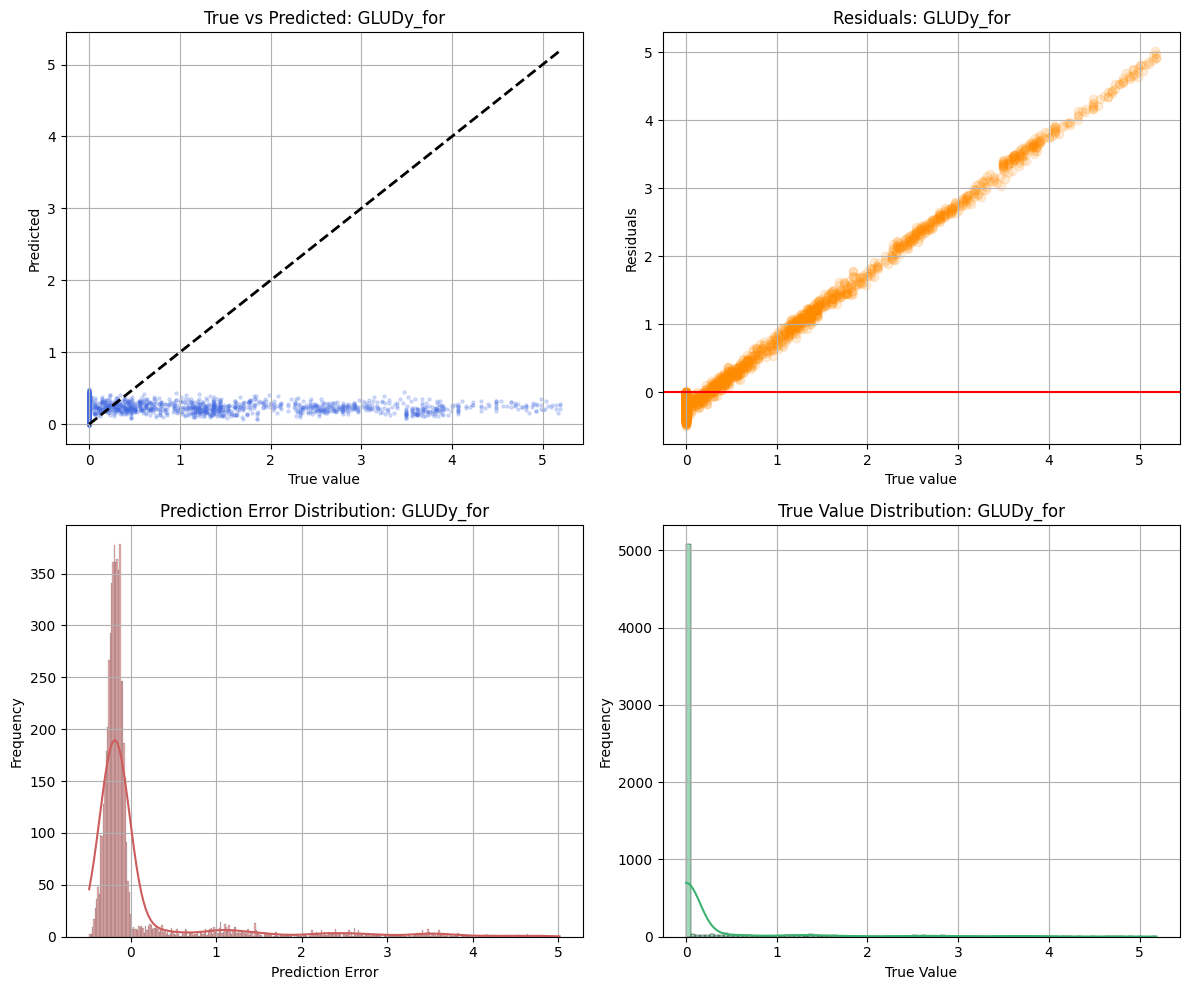

Number of parameters:
13770


In [128]:
plot_prediction_sample(X_test, y_test, model_1622)

for flux_name in diagnostics_to_plot:
    plot_flux(model_1622, X_test, y_test, output_cols, flux_name)

print('Number of parameters:')
print(sum( p.numel() for p in model_1622.parameters() if p.requires_grad ))

In [129]:
train_losses_3242, test_losses_3242, model_3242, optimizer = train_model(d_model=32, n_heads=4, n_layers=2, d_ff=128, num_epochs=num_epochs, dropout=dropout, output_sample_ratio=output_sample_ratio)



Epoch 2/40 | Train Loss: 2.343137 | Test Loss: 2.761287
Epoch 4/40 | Train Loss: 1.517115 | Test Loss: 2.491338
Epoch 6/40 | Train Loss: 1.201626 | Test Loss: 2.732389
Epoch 8/40 | Train Loss: 1.102322 | Test Loss: 3.189893
Epoch 10/40 | Train Loss: 0.921725 | Test Loss: 3.574036
Epoch 12/40 | Train Loss: 0.780006 | Test Loss: 3.371029
Epoch 14/40 | Train Loss: 0.717055 | Test Loss: 3.008599
Epoch 16/40 | Train Loss: 0.637982 | Test Loss: 2.879164
Epoch 18/40 | Train Loss: 0.544902 | Test Loss: 2.703141
Epoch 20/40 | Train Loss: 0.507485 | Test Loss: 2.660616
Epoch 22/40 | Train Loss: 0.466969 | Test Loss: 2.678262
Epoch 24/40 | Train Loss: 0.426931 | Test Loss: 2.626679
Epoch 26/40 | Train Loss: 0.401653 | Test Loss: 2.596816
Epoch 28/40 | Train Loss: 0.378440 | Test Loss: 2.613747
Epoch 30/40 | Train Loss: 0.361078 | Test Loss: 2.554730
Epoch 32/40 | Train Loss: 0.343157 | Test Loss: 2.462470
Epoch 34/40 | Train Loss: 0.325125 | Test Loss: 2.417450
Epoch 36/40 | Train Loss: 0.314042 

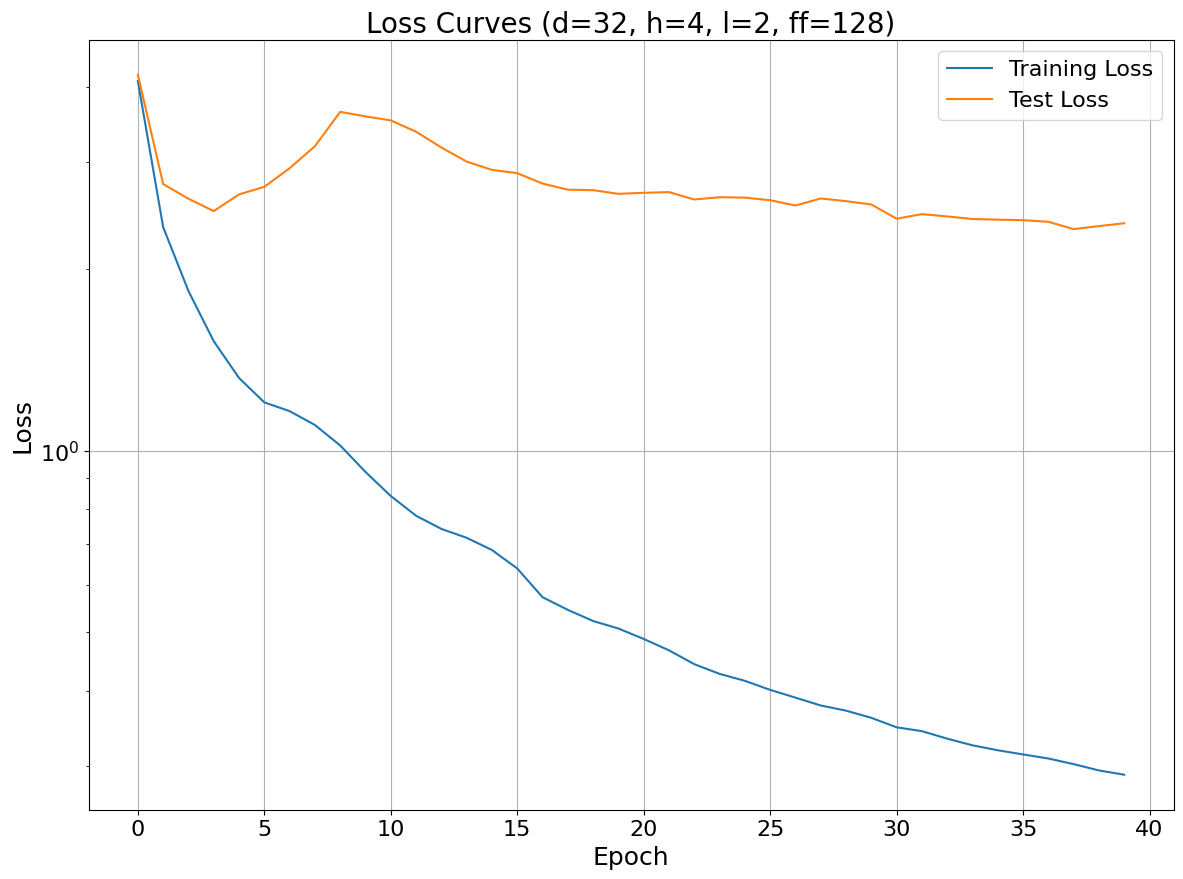

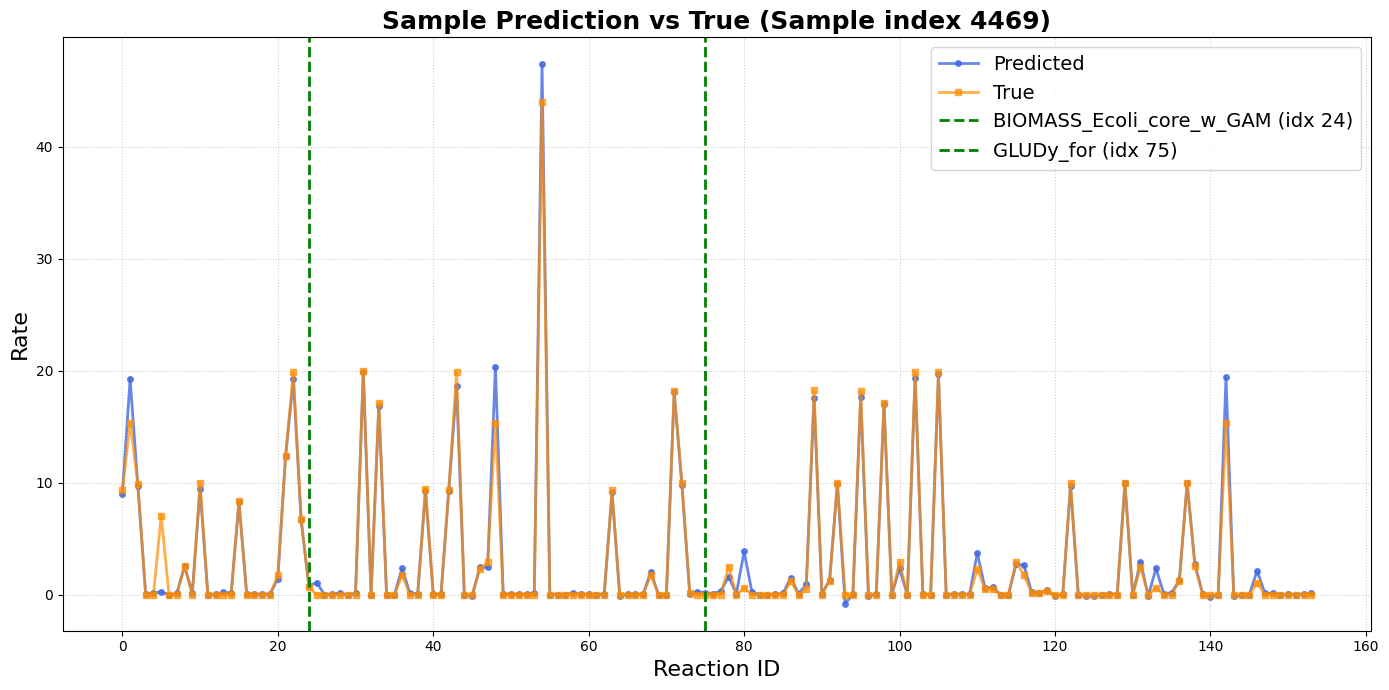

(6160, 154) (6160, 154)
y_pred_outputs.shape: (6160, 154) min/max: -2.0685163 71.86487
y_true_outputs.shape: (6160, 154) min/max: 0.0 86.397766
BIOMASS_Ecoli_core_w_GAM index in outputs: 24
y_true_outputs[:, idx] range: 0.5590506 to 1.2481481
y_pred_outputs[:, _idx] range: 0.7293922 to 0.99465054


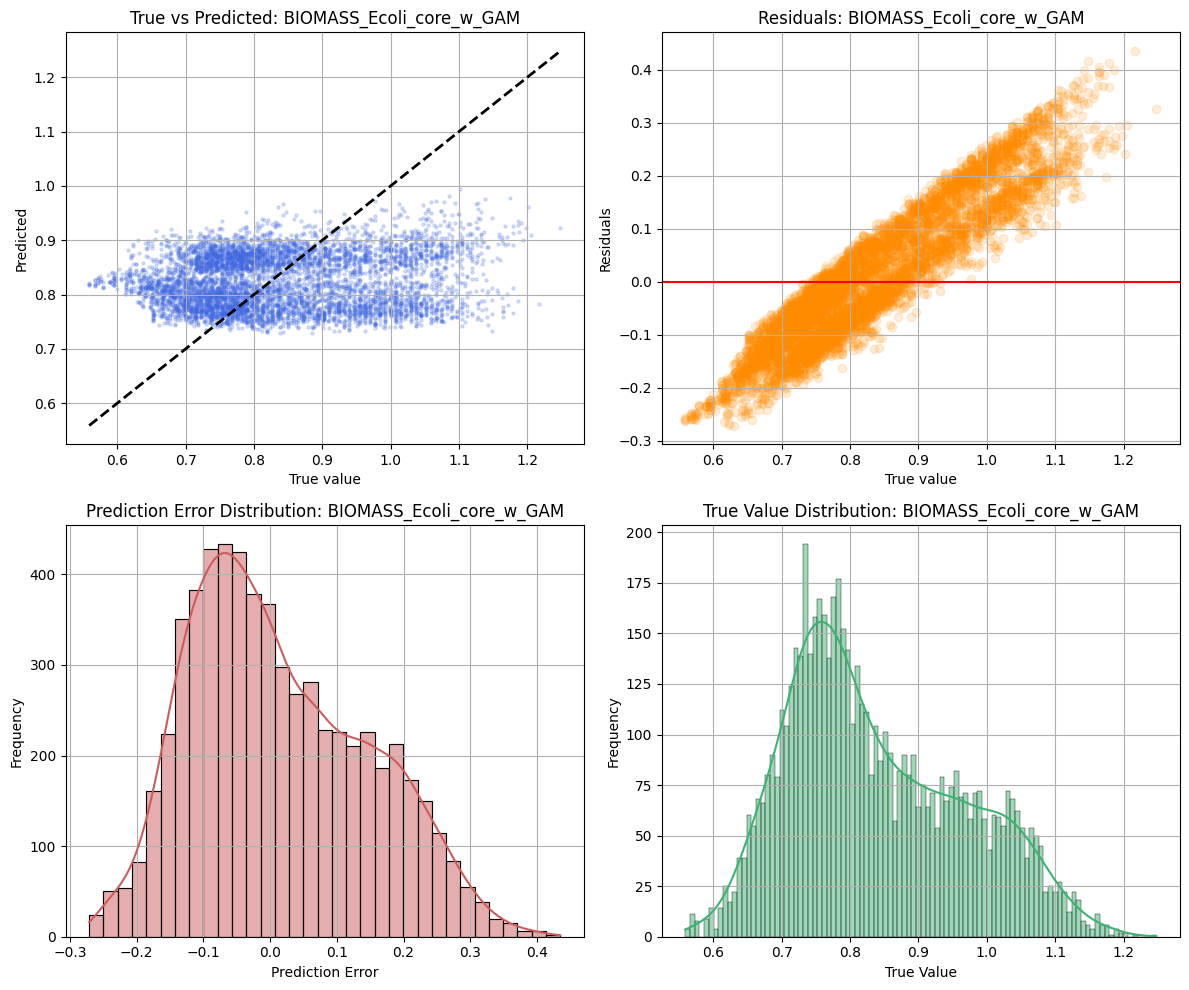

(6160, 154) (6160, 154)
y_pred_outputs.shape: (6160, 154) min/max: -2.0685163 71.86487
y_true_outputs.shape: (6160, 154) min/max: 0.0 86.397766
GLUDy_for index in outputs: 75
y_true_outputs[:, idx] range: 0.0 to 5.187185
y_pred_outputs[:, _idx] range: -0.14839947 to 0.9388513


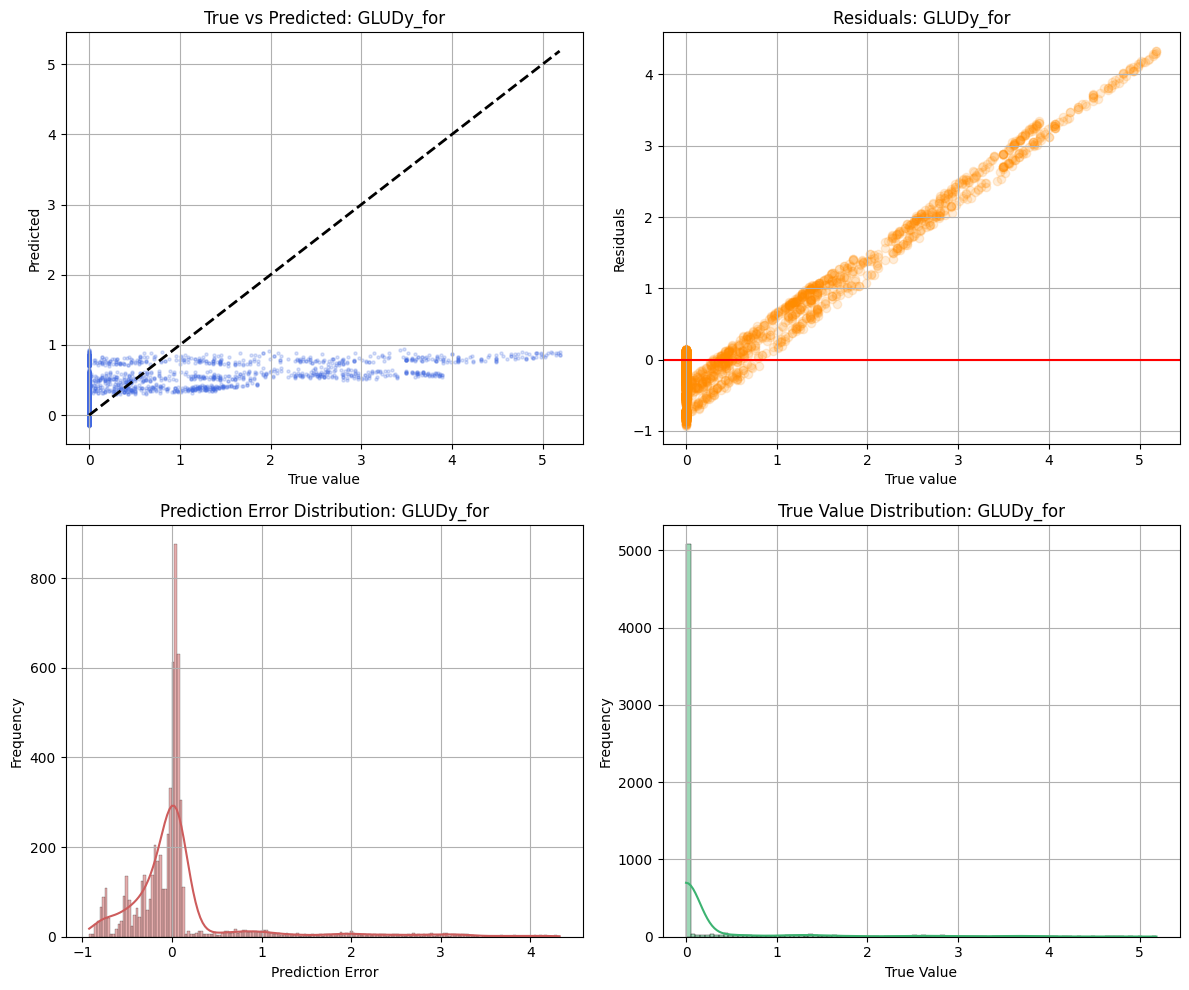

Number of parameters:
30862


In [130]:
model_3242.to('mps')
plot_loss_curves(train_losses_3242, test_losses_3242, d_model=32, n_heads=4, n_layers=2, d_ff=128)

plot_prediction_sample(X_test, y_test, model_3242)

for flux_name in diagnostics_to_plot:
    plot_flux(model_3242, X_test, y_test, output_cols, flux_name)

print('Number of parameters:')
print(sum( p.numel() for p in model_3242.parameters() if p.requires_grad ))

In [109]:
train_losses_3243_256, test_losses_3243_256, model_3243_256, optimizer = train_model(d_model=32, n_heads=4, n_layers=3, d_ff=256, num_epochs=num_epochs, dropout=dropout, output_sample_ratio=output_sample_ratio)



Epoch 2/40 | Train Loss: 2.701183 | Test Loss: 3.781027
Epoch 4/40 | Train Loss: 1.434709 | Test Loss: 2.798446
Epoch 6/40 | Train Loss: 1.165946 | Test Loss: 3.136125
Epoch 8/40 | Train Loss: 0.927083 | Test Loss: 3.199857
Epoch 10/40 | Train Loss: 0.775703 | Test Loss: 3.172223
Epoch 12/40 | Train Loss: 0.676213 | Test Loss: 3.237487
Epoch 14/40 | Train Loss: 0.588577 | Test Loss: 3.659538
Epoch 16/40 | Train Loss: 0.505201 | Test Loss: 3.515801
Epoch 18/40 | Train Loss: 0.455119 | Test Loss: 3.259593
Epoch 20/40 | Train Loss: 0.421444 | Test Loss: 3.168983
Epoch 22/40 | Train Loss: 0.390765 | Test Loss: 3.168969
Epoch 24/40 | Train Loss: 0.368246 | Test Loss: 3.120950
Epoch 26/40 | Train Loss: 0.353660 | Test Loss: 3.075804
Epoch 28/40 | Train Loss: 0.336761 | Test Loss: 3.032213
Epoch 30/40 | Train Loss: 0.319904 | Test Loss: 2.996662
Epoch 32/40 | Train Loss: 0.306225 | Test Loss: 2.903122
Epoch 34/40 | Train Loss: 0.295227 | Test Loss: 2.868555
Epoch 36/40 | Train Loss: 0.281193 

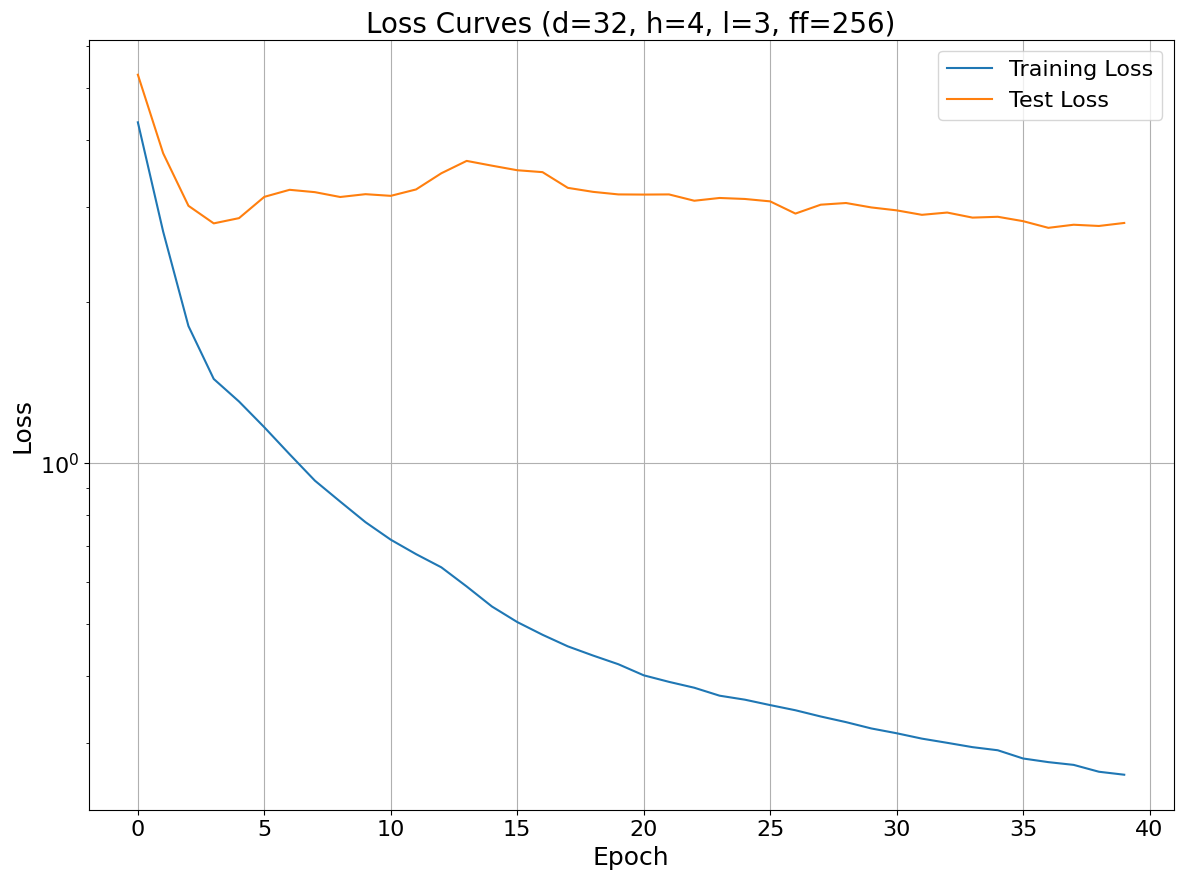

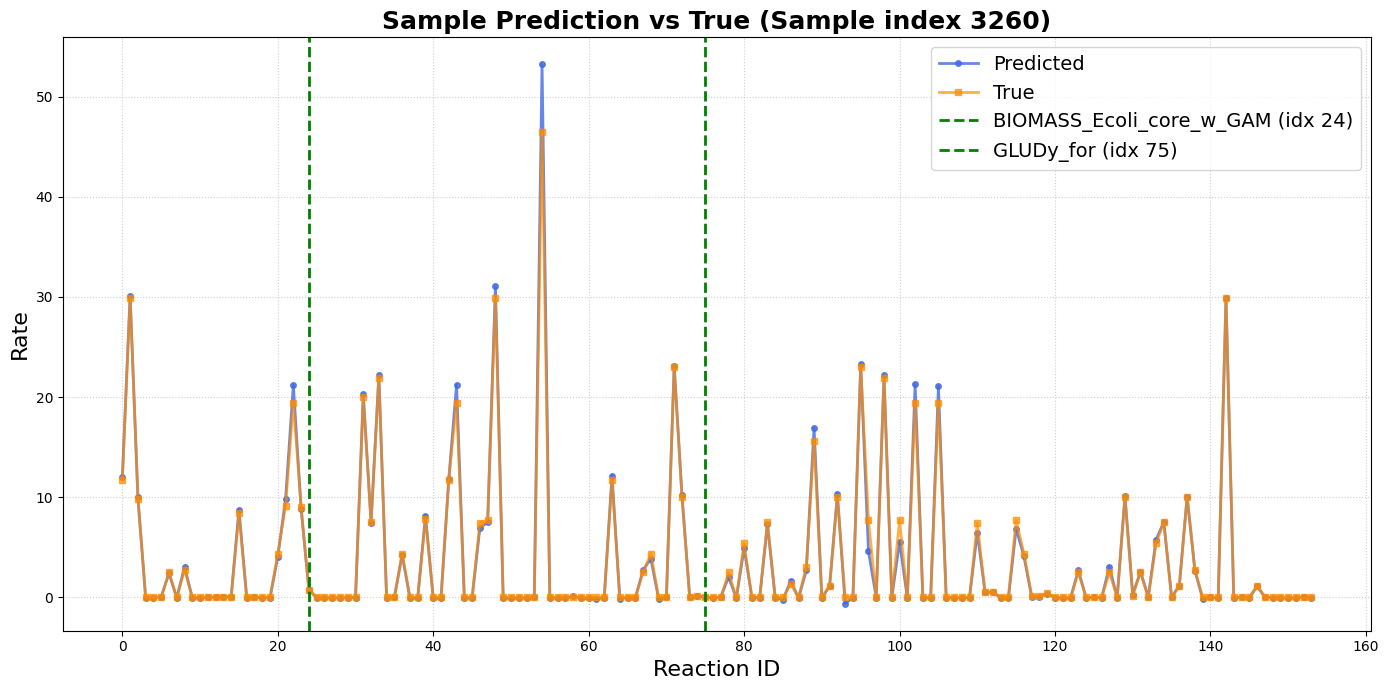

(6160, 154) (6160, 154)
y_pred_outputs.shape: (6160, 154) min/max: -1.2313223 75.36621
y_true_outputs.shape: (6160, 154) min/max: 0.0 86.397766
BIOMASS_Ecoli_core_w_GAM index in outputs: 24
y_true_outputs[:, idx] range: 0.5590506 to 1.2481481
y_pred_outputs[:, _idx] range: 0.70329773 to 0.8918544


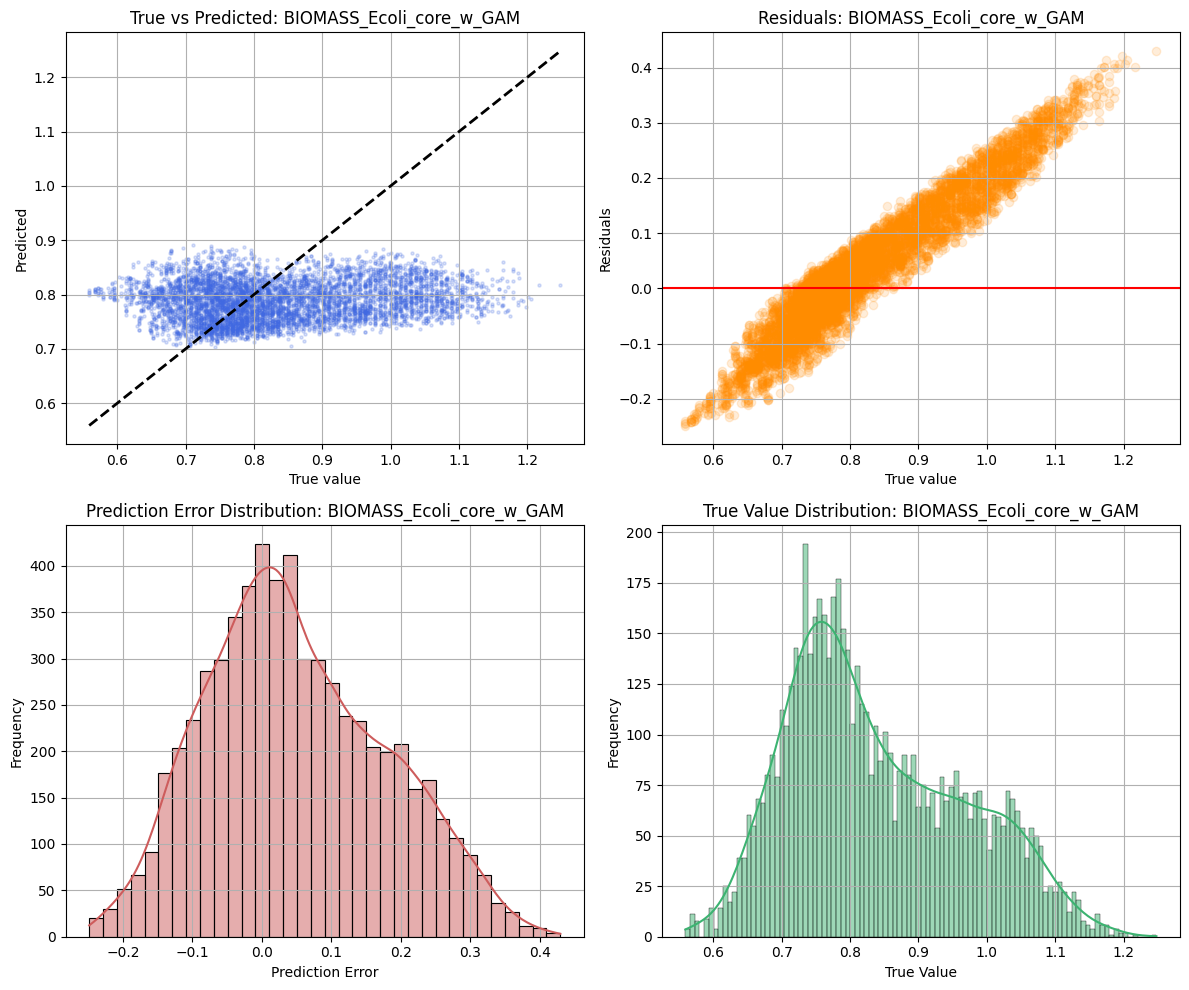

(6160, 154) (6160, 154)
y_pred_outputs.shape: (6160, 154) min/max: -1.2313223 75.36621
y_true_outputs.shape: (6160, 154) min/max: 0.0 86.397766
GLUDy_for index in outputs: 75
y_true_outputs[:, idx] range: 0.0 to 5.187185
y_pred_outputs[:, _idx] range: -0.17990315 to 0.631037


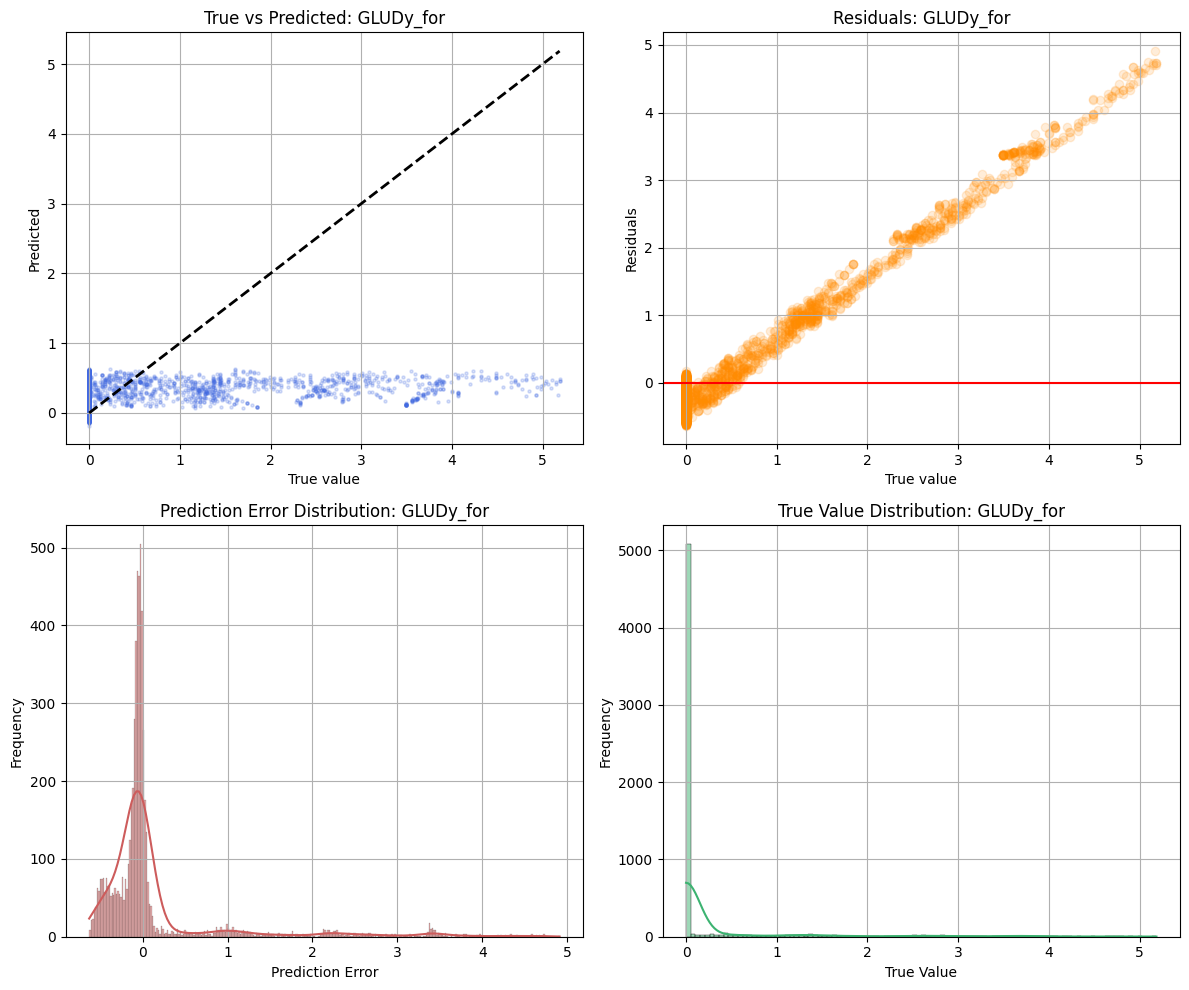

Number of parameters:
69557


In [110]:
model_3243_256.to('mps')
plot_loss_curves(train_losses_3243_256, test_losses_3243_256, d_model=32, n_heads=4, n_layers=3, d_ff=256)

plot_prediction_sample(X_test, y_test, model_3243_256)

for flux_name in diagnostics_to_plot:
    plot_flux(model_3243_256, X_test, y_test, output_cols, flux_name)

print('Number of parameters:')
print(sum( p.numel() for p in model_3243_256.parameters() if p.requires_grad ))

In [111]:
train_losses_6443_256, test_losses_6443_256, model_6443_256, optimizer = train_model(d_model=64, n_heads=4, n_layers=3, d_ff=256, num_epochs=num_epochs, dropout=dropout, output_sample_ratio=output_sample_ratio)



Epoch 2/40 | Train Loss: 1.602516 | Test Loss: 2.958270
Epoch 4/40 | Train Loss: 1.036472 | Test Loss: 3.390827
Epoch 6/40 | Train Loss: 0.701697 | Test Loss: 3.148489
Epoch 8/40 | Train Loss: 0.544403 | Test Loss: 2.864778
Epoch 10/40 | Train Loss: 0.473343 | Test Loss: 2.538355
Epoch 12/40 | Train Loss: 0.411466 | Test Loss: 2.371248
Epoch 14/40 | Train Loss: 0.366066 | Test Loss: 2.507484
Epoch 16/40 | Train Loss: 0.336913 | Test Loss: 2.453061
Epoch 18/40 | Train Loss: 0.303909 | Test Loss: 2.376724
Epoch 20/40 | Train Loss: 0.288545 | Test Loss: 2.441127
Epoch 22/40 | Train Loss: 0.266271 | Test Loss: 2.435759
Epoch 24/40 | Train Loss: 0.248904 | Test Loss: 2.434364
Epoch 26/40 | Train Loss: 0.234282 | Test Loss: 2.480620
Epoch 28/40 | Train Loss: 0.222863 | Test Loss: 2.400625
Epoch 30/40 | Train Loss: 0.215651 | Test Loss: 2.406364
Epoch 32/40 | Train Loss: 0.210884 | Test Loss: 2.415838
Epoch 34/40 | Train Loss: 0.199361 | Test Loss: 2.410942
Epoch 36/40 | Train Loss: 0.192405 

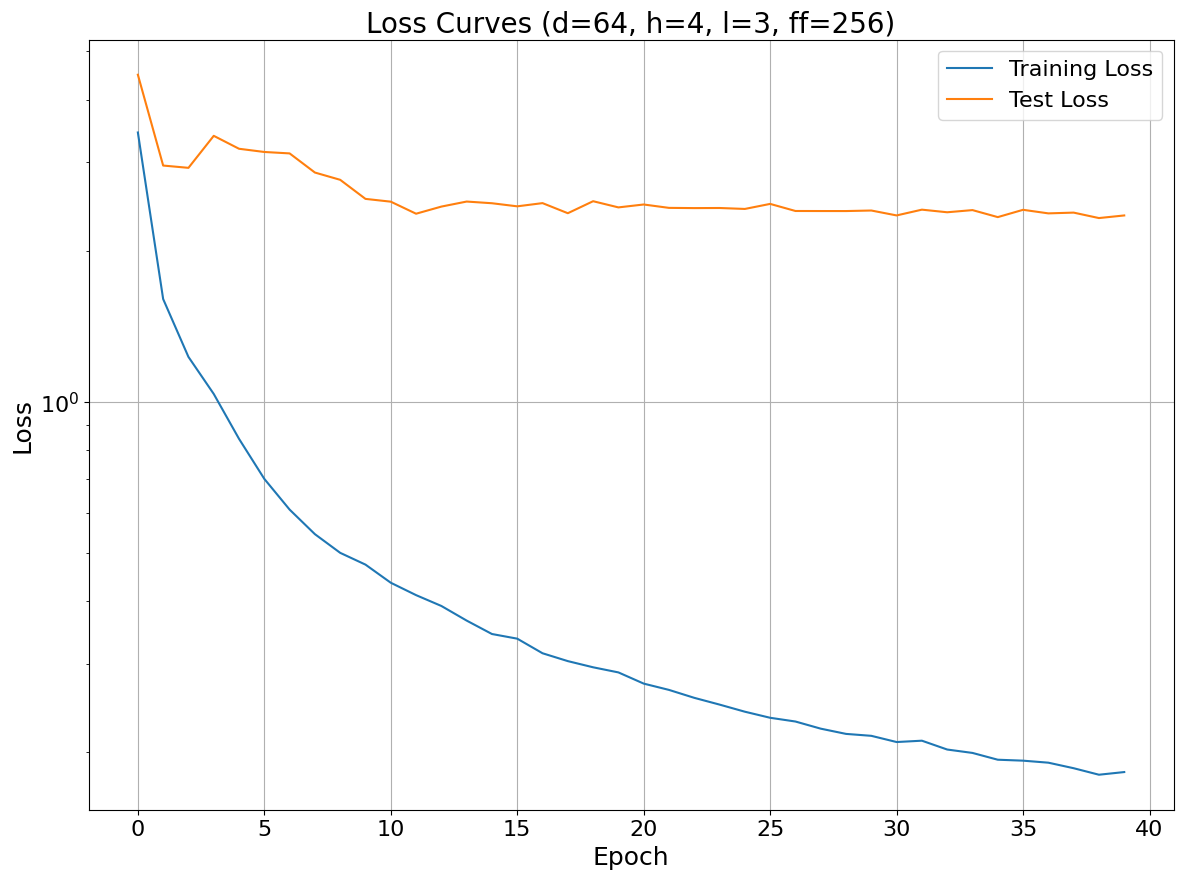

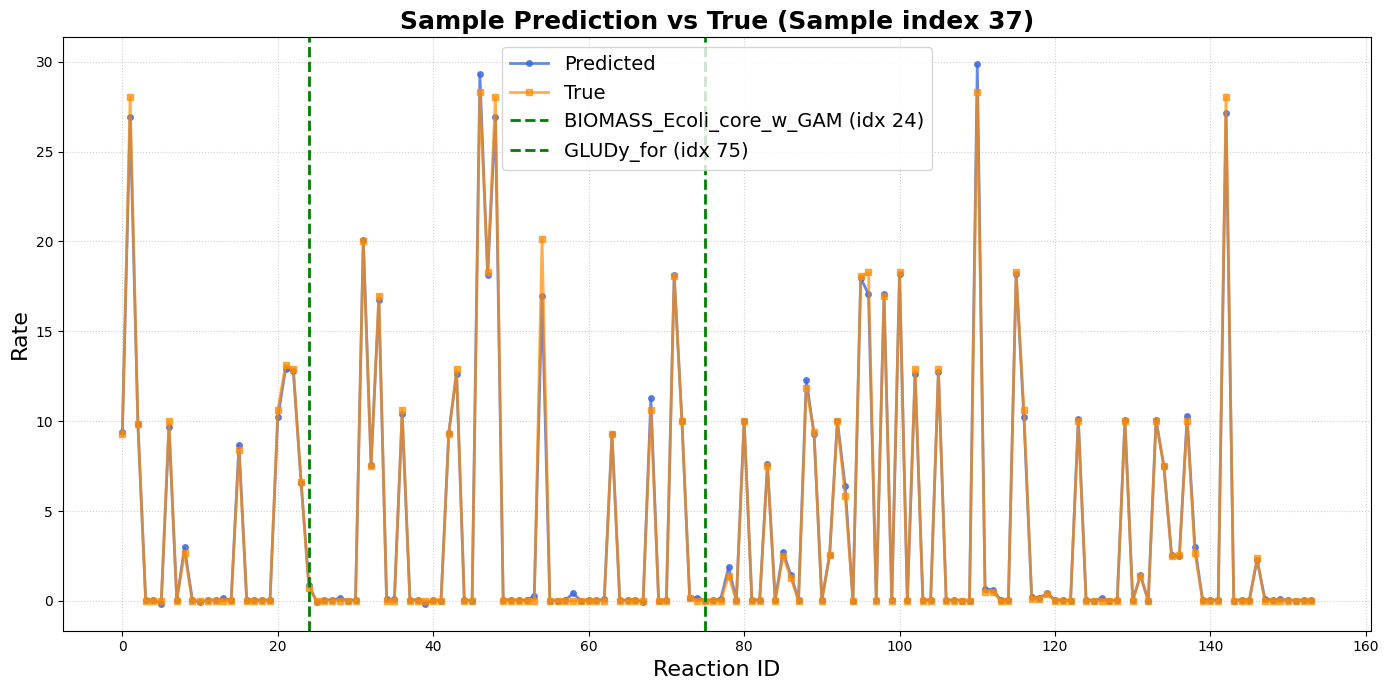

(6160, 154) (6160, 154)
y_pred_outputs.shape: (6160, 154) min/max: -1.7296691 76.408104
y_true_outputs.shape: (6160, 154) min/max: 0.0 86.397766
BIOMASS_Ecoli_core_w_GAM index in outputs: 24
y_true_outputs[:, idx] range: 0.5590506 to 1.2481481
y_pred_outputs[:, _idx] range: 0.6548004 to 1.3043935


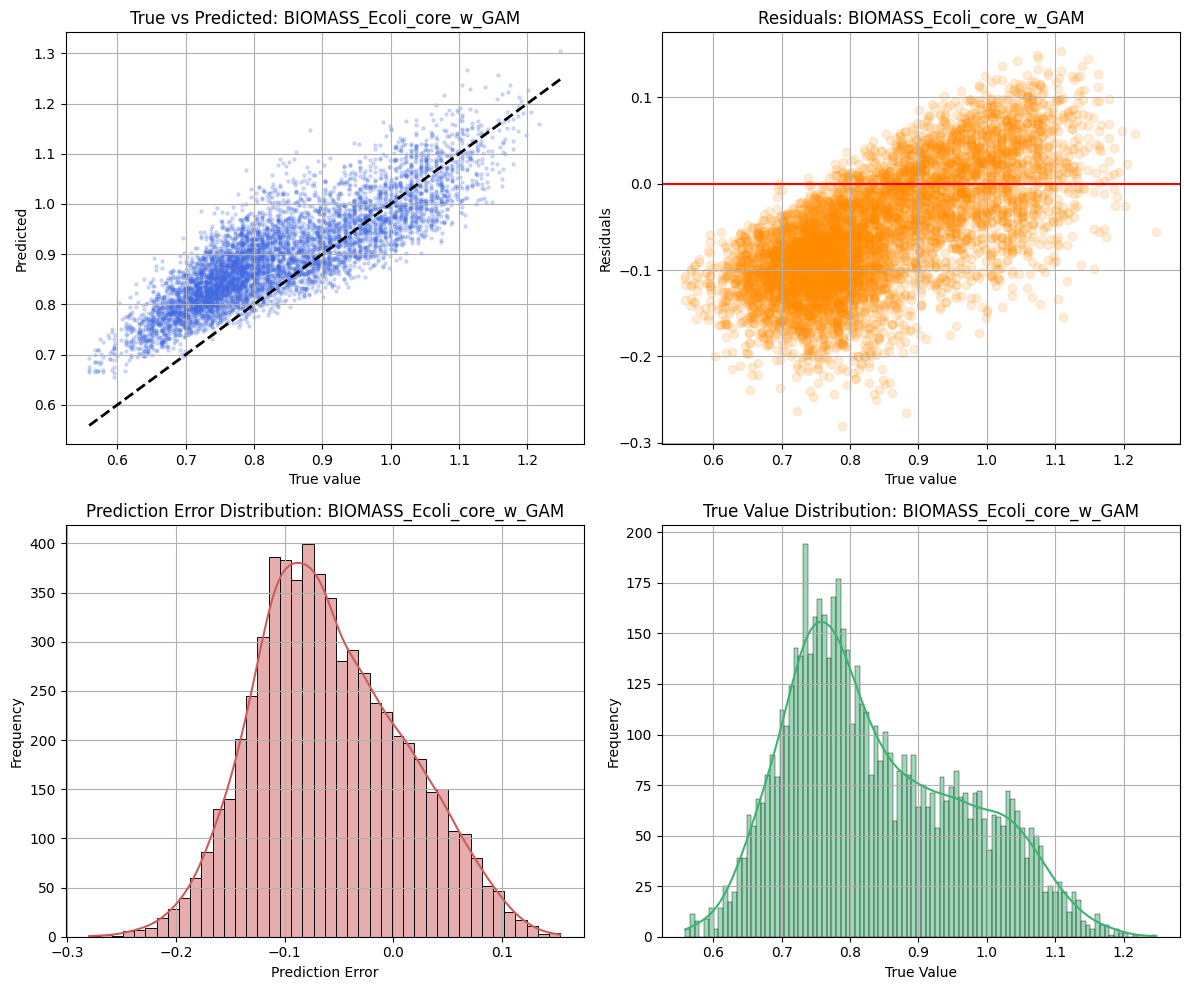

(6160, 154) (6160, 154)
y_pred_outputs.shape: (6160, 154) min/max: -1.7296691 76.408104
y_true_outputs.shape: (6160, 154) min/max: 0.0 86.397766
GLUDy_for index in outputs: 75
y_true_outputs[:, idx] range: 0.0 to 5.187185
y_pred_outputs[:, _idx] range: -0.12579465 to 4.87091


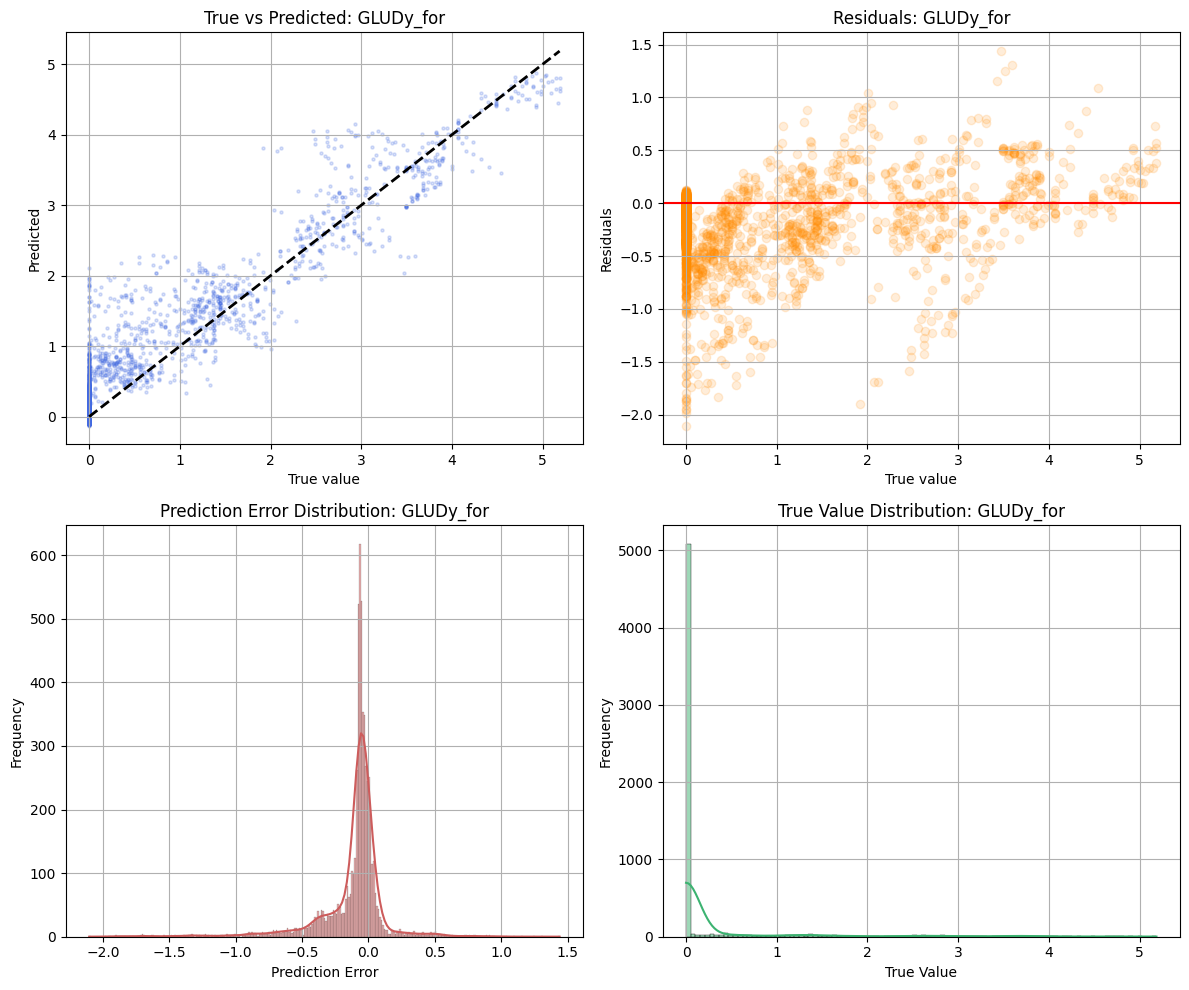

Number of parameters:
161365


In [112]:
model_6443_256.to('mps')
plot_loss_curves(train_losses_6443_256, test_losses_6443_256, d_model=64, n_heads=4, n_layers=3, d_ff=256)

plot_prediction_sample(X_test, y_test, model_6443_256)

for flux_name in diagnostics_to_plot:
    plot_flux(model_6443_256, X_test, y_test, output_cols, flux_name)

print('Number of parameters:')
print(sum( p.numel() for p in model_6443_256.parameters() if p.requires_grad ))